# Setup / Data Overview

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import HistGradientBoostingClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score, roc_auc_score
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import optuna
from optuna.samplers import TPESampler
import time
import joblib

In [2]:
file_path = "/kaggle/input/datasets/alphiree/cardiovascular-diseases-risk-prediction-dataset/CVD_cleaned.csv"
cvd = pd.read_csv(file_path)

In [3]:
cvd.head()

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,Poor,Within the past 2 years,No,No,No,No,No,No,Yes,Female,70-74,150.0,32.66,14.54,Yes,0.0,30.0,16.0,12.0
1,Very Good,Within the past year,No,Yes,No,No,No,Yes,No,Female,70-74,165.0,77.11,28.29,No,0.0,30.0,0.0,4.0
2,Very Good,Within the past year,Yes,No,No,No,No,Yes,No,Female,60-64,163.0,88.45,33.47,No,4.0,12.0,3.0,16.0
3,Poor,Within the past year,Yes,Yes,No,No,No,Yes,No,Male,75-79,180.0,93.44,28.73,No,0.0,30.0,30.0,8.0
4,Good,Within the past year,No,No,No,No,No,No,No,Male,80+,191.0,88.45,24.37,Yes,0.0,8.0,4.0,0.0


In [4]:
cvd.describe()

,Height_(cm),Weight_(kg),BMI,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
count,308854.000000,308854.000000,308854.000000,308854.000000,308854.000000,308854.000000,308854.000000
mean,170.615249,83.588655,28.626211,5.096366,29.835200,15.110441,6.296616
std,10.658026,21.343210,6.522323,8.199763,24.875735,14.926238,8.582954
min,91.000000,24.950000,12.020000,0.000000,0.000000,0.000000,0.000000
25%,163.000000,68.040000,24.210000,0.000000,12.000000,4.000000,2.000000
50%,170.000000,81.650000,27.440000,1.000000,30.000000,12.000000,4.000000
75%,178.000000,95.250000,31.850000,6.000000,30.000000,20.000000,8.000000
max,241.000000,293.020000,99.330000,30.000000,120.000000,128.000000,128.000000


In [5]:
cvd.describe(include=["object"])

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Smoking_History
count,308854,308854,308854,308854,308854,308854,308854,308854,308854,308854,308854,308854
unique,5,5,2,2,2,2,2,4,2,2,13,2
top,Very Good,Within the past year,Yes,No,No,No,No,No,No,Female,65-69,No
freq,110395,239371,239381,283883,278860,278976,246953,259141,207783,160196,33434,183590


In [6]:
cvd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308854 entries, 0 to 308853
Data columns (total 19 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   General_Health                308854 non-null  object 
 1   Checkup                       308854 non-null  object 
 2   Exercise                      308854 non-null  object 
 3   Heart_Disease                 308854 non-null  object 
 4   Skin_Cancer                   308854 non-null  object 
 5   Other_Cancer                  308854 non-null  object 
 6   Depression                    308854 non-null  object 
 7   Diabetes                      308854 non-null  object 
 8   Arthritis                     308854 non-null  object 
 9   Sex                           308854 non-null  object 
 10  Age_Category                  308854 non-null  object 
 11  Height_(cm)                   308854 non-null  float64
 12  Weight_(kg)                   308854 non-nul

# Section A: Target Distribution

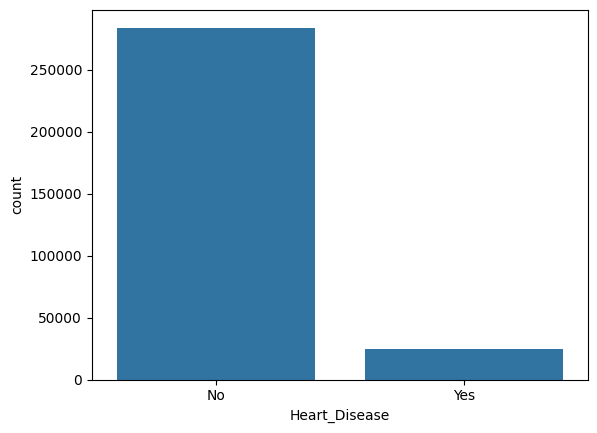

In [7]:
sns.countplot(x="Heart_Disease", data=cvd)
plt.show()

# The chart above shows that :
**`Heart_Disease` is heavily imbalanced toward `No` — most respondents do not have heart disease, confirming this is a rare-event classification problem where plain accuracy would be a misleading metric.**


# Section B: Demographics vs Heart Disease

In [8]:
ct_prt = pd.crosstab(
    cvd.Age_Category,
    cvd.Heart_Disease,
    normalize='index'
) * 100

ct_prt = ct_prt.round(2)

ct_prt

Heart_Disease,No,Yes
Age_Category,,
18-24,99.50,0.50
25-29,99.27,0.73
30-34,98.91,1.09
35-39,98.67,1.33
40-44,97.99,2.01
45-49,96.77,3.23
50-54,95.29,4.71
55-59,92.90,7.10
60-64,90.71,9.29


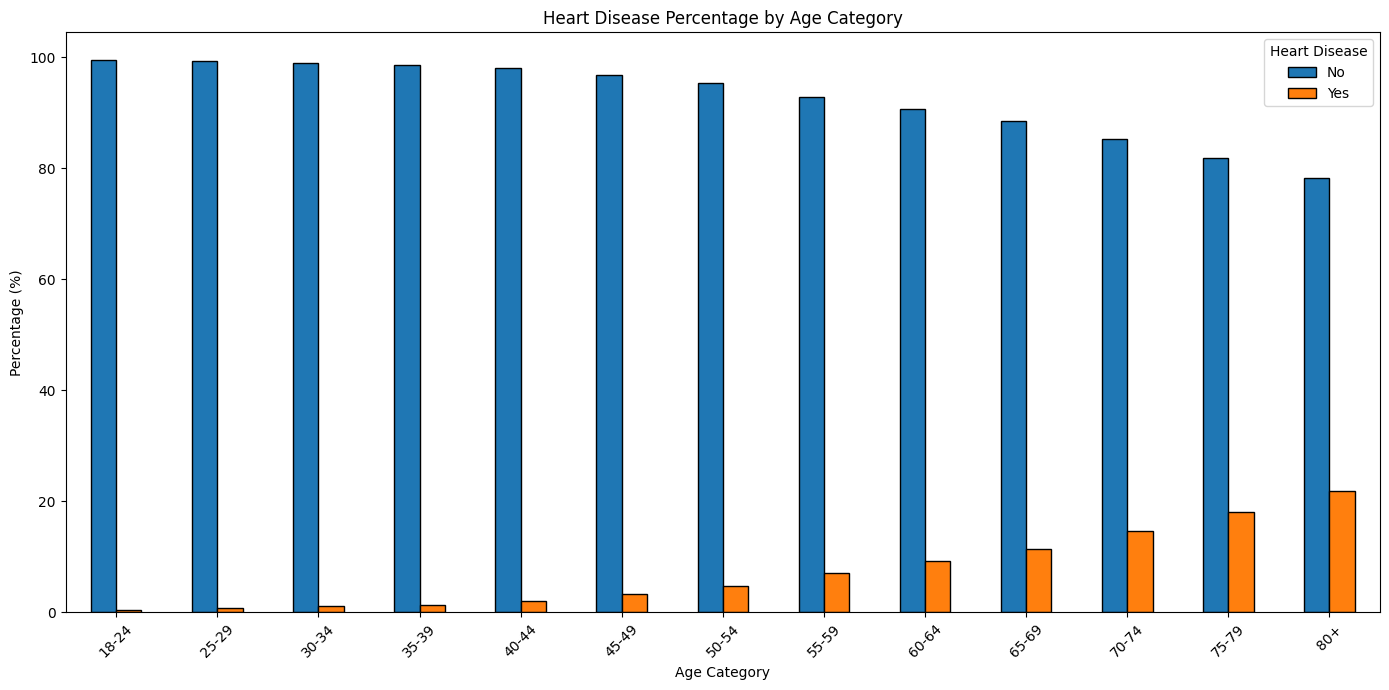

In [9]:
ax = ct_prt.plot(
    kind='bar',
    figsize=(14, 7),
    edgecolor='black'
)

plt.title('Heart Disease Percentage by Age Category')
plt.xlabel('Age Category')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45)
plt.legend(title='Heart Disease')
plt.tight_layout()
plt.show()

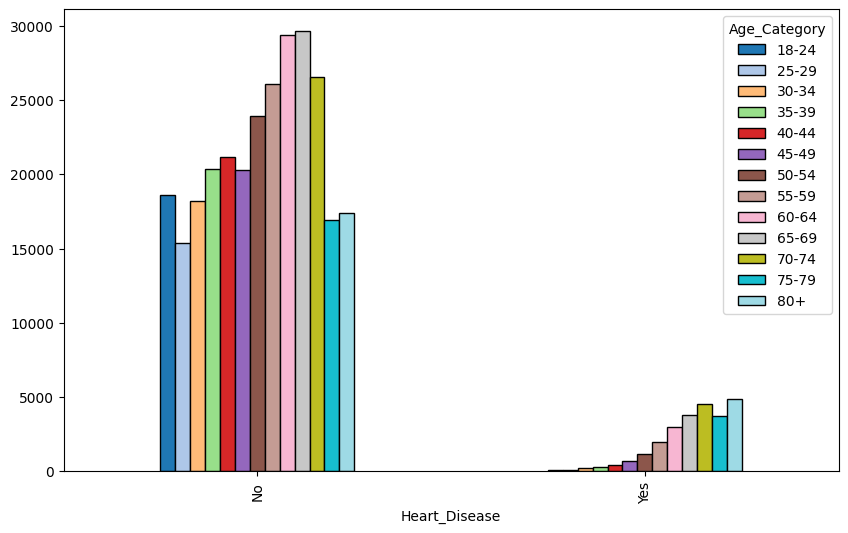

In [10]:
ct_count = pd.crosstab(cvd.Heart_Disease, cvd.Age_Category)
ct_count.plot(kind="bar", figsize=(10,6),colormap="tab20", edgecolor="black")
plt.show()

# The plot above shows that :
**Heart disease cases are much more prevalent in the `older age` categories than in the `younger age` categories.**

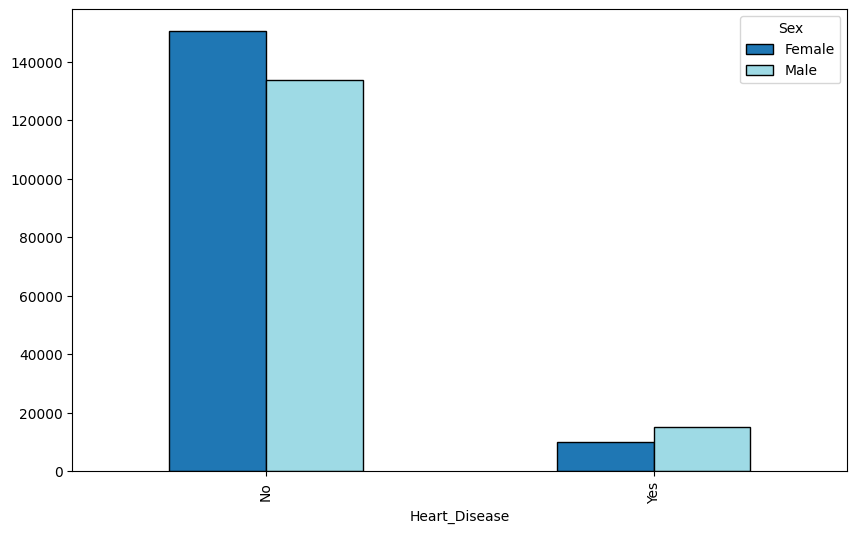

In [11]:
ct = pd.crosstab(cvd.Heart_Disease, cvd.Sex)
ct.plot(kind="bar", figsize=(10,6),colormap="tab20", edgecolor="black")
plt.show()

# The chart above shows that :
**More heart disease cases are recorded among males than females in absolute counts, though this partly reflects that males also make up a larger share of respondents overall.**


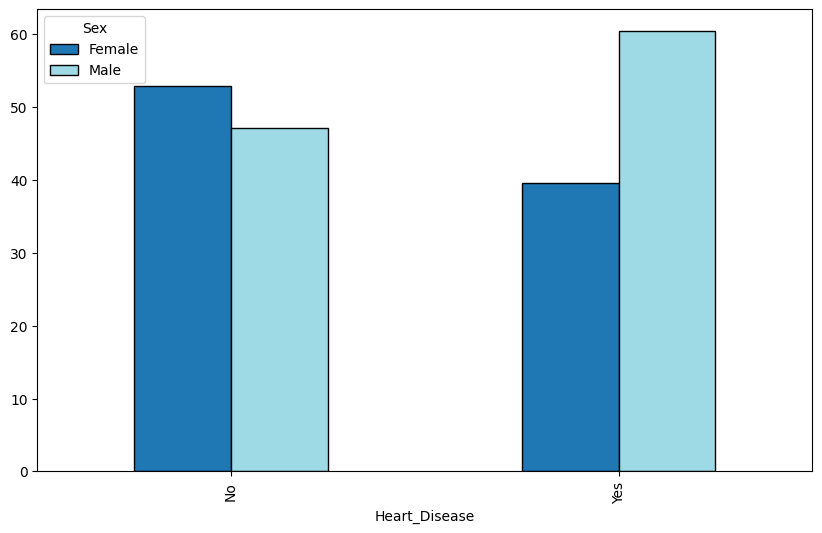

In [12]:
ct = pd.crosstab(
    cvd.Heart_Disease,
    cvd.Sex,
    normalize = 'index'
    ) * 100
ct.plot(kind="bar", figsize=(10,6),colormap="tab20", edgecolor="black")
plt.show()

# The chart above shows that :
**Males are more prone to heart disease than females on a rate basis, not just in raw counts — confirming the classic sex-based cardiovascular risk differential.**


In [13]:
age_sex_ct = pd.crosstab(
    cvd.Age_Category,
    cvd.Sex,
    normalize='index'
) * 100

age_sex_ct = age_sex_ct.round(2)

age_sex_ct

Sex,Female,Male
Age_Category,,
18-24,43.98,56.02
25-29,45.94,54.06
30-34,48.64,51.36
35-39,50.31,49.69
40-44,51.88,48.12
45-49,52.46,47.54
50-54,51.67,48.33
55-59,52.26,47.74
60-64,52.34,47.66


# The chart above shows that :
**The female share of each age group rises steadily with age, from about 44% of 18-24 year olds to about 59% of the 80+ group, reflecting the well-known longer average female lifespan seen in survey populations like this one.**


### Heart Disease Rate by Age Category and Sex (Heatmap)
Interaction view: combines the Age and Sex breakdowns above into a single rate table.

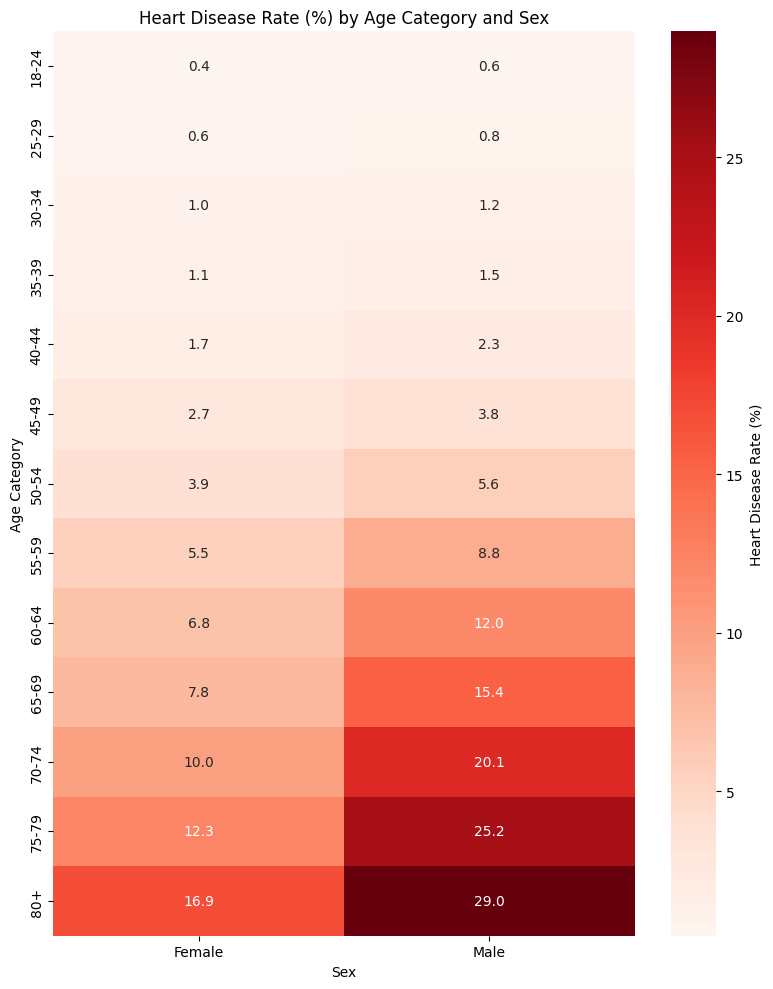

In [14]:
age_sex_heart_rate = (
    cvd.groupby(['Age_Category', 'Sex'])['Heart_Disease']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .unstack()
    .round(2)
)

plt.figure(figsize=(8, 10))
sns.heatmap(age_sex_heart_rate, annot=True, fmt='.1f', cmap='Reds', cbar_kws={'label': 'Heart Disease Rate (%)'})
plt.title('Heart Disease Rate (%) by Age Category and Sex')
plt.xlabel('Sex')
plt.ylabel('Age Category')
plt.tight_layout()
plt.show()


# The chart above shows that :
**Heart disease rate rises with age for both sexes, but males consistently have a higher rate than females within every age band — the age effect and the sex effect compound rather than one dominating the other.**


In [15]:
gen_heart_ct = pd.crosstab(
    cvd.General_Health,
    cvd.Heart_Disease,
    normalize='index'
) * 100

gen_heart_ct = gen_heart_ct.round(2)

gen_heart_ct

Heart_Disease,No,Yes
General_Health,,
Excellent,98.01,1.99
Fair,81.04,18.96
Good,90.94,9.06
Poor,68.21,31.79
Very Good,95.63,4.37


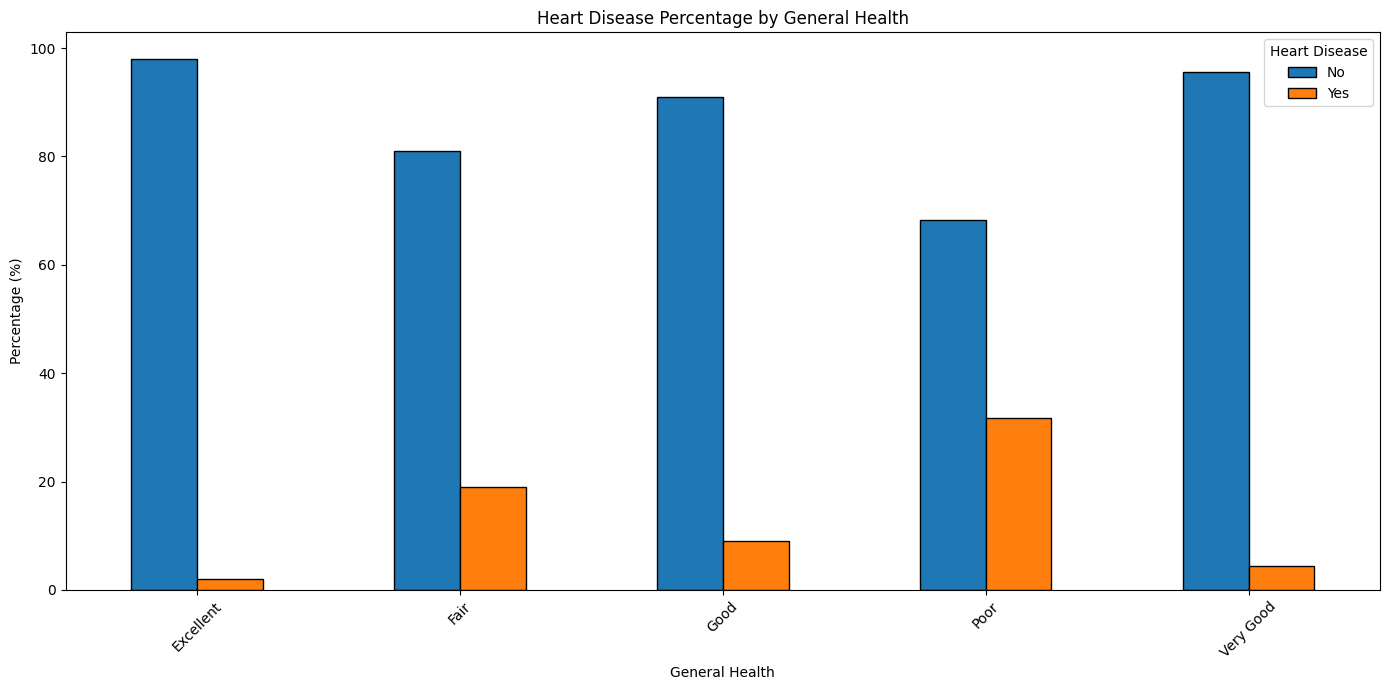

In [16]:
gen_heart_ct.plot(
    kind='bar',
    figsize=(14, 7),
    edgecolor='black',
    stacked = False
)

plt.title('Heart Disease Percentage by General Health')
plt.xlabel('General Health')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45)
plt.legend(title='Heart Disease')
plt.tight_layout()
plt.show()

# The chart above shows that :
**There is a clear gradient: heart disease rate rises steadily as self-rated `General_Health` worsens, from about 2% among those reporting `Excellent` health to nearly 32% among those reporting `Poor` health — confirming self-rated health as a strong proxy for actual cardiovascular risk.**


In [17]:
check_age_ct = pd.crosstab(
    cvd.Checkup,
    cvd.Age_Category,
    normalize='index'
) * 100

check_age_ct = check_age_ct.round(2)

check_age_ct

Age_Category,18-24,25-29,30-34,35-39,40-44,45-49,50-54,55-59,60-64,65-69,70-74,75-79,80+
Checkup,,,,,,,,,,,,,
5 or more years ago,7.37,11.47,12.79,12.01,10.19,8.16,8.08,8.43,8.82,5.70,3.64,1.74,1.58
Never,11.02,10.66,10.66,11.73,10.73,8.03,6.47,7.39,7.89,5.61,3.62,3.13,3.06
Within the past 2 years,9.84,7.54,8.59,9.41,9.28,8.26,8.77,9.05,9.33,7.39,5.86,3.37,3.32
Within the past 5 years,12.80,10.62,10.91,11.53,9.92,8.56,8.12,8.13,7.54,5.13,3.27,1.75,1.72
Within the past year,4.86,3.82,4.79,5.56,6.22,6.35,8.04,9.20,11.00,12.09,11.62,7.88,8.56


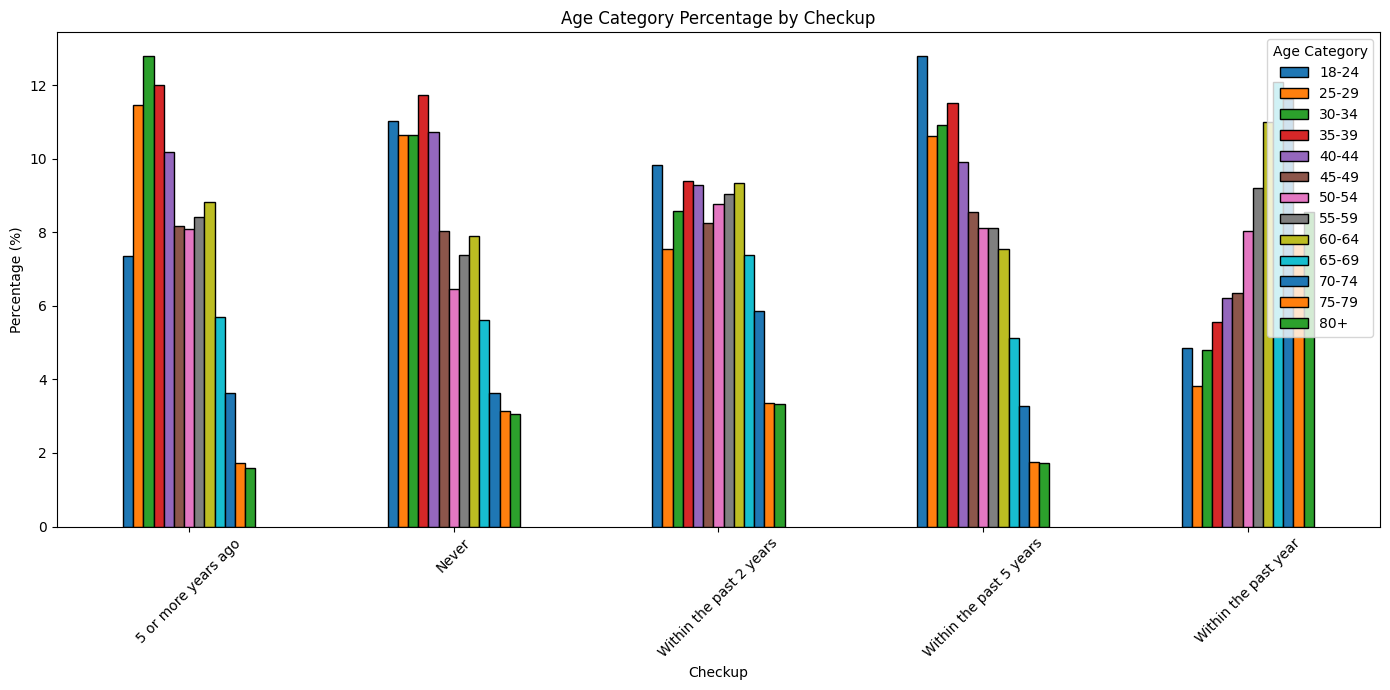

In [18]:
check_age_chart = check_age_ct.plot(
    kind='bar',
    figsize=(14, 7),
    edgecolor='black',
    stacked = False
)

plt.title('Age Category Percentage by Checkup')
plt.xlabel('Checkup')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45)
plt.legend(title='Age Category')
plt.tight_layout()
plt.show()

# The chart above shows that :
**Younger respondents (18-39) are more likely to report never having a checkup or one 5+ years ago, while respondents aged 60+ are far more likely to have had a checkup within the past year — screening behavior improves noticeably with age.**


In [19]:
check_gen_ct = pd.crosstab(
    cvd.Checkup,
    cvd.General_Health,
    normalize='index'
) * 100

check_gen_ct = check_gen_ct.round(2)

check_gen_ct

General_Health,Excellent,Fair,Good,Poor,Very Good
Checkup,,,,,
5 or more years ago,26.24,8.83,28.30,2.10,34.54
Never,27.51,11.66,28.50,3.98,28.36
Within the past 2 years,22.56,8.28,28.53,2.12,38.52
Within the past 5 years,23.73,8.03,28.67,1.86,37.71
Within the past year,16.51,12.52,31.56,4.13,35.28


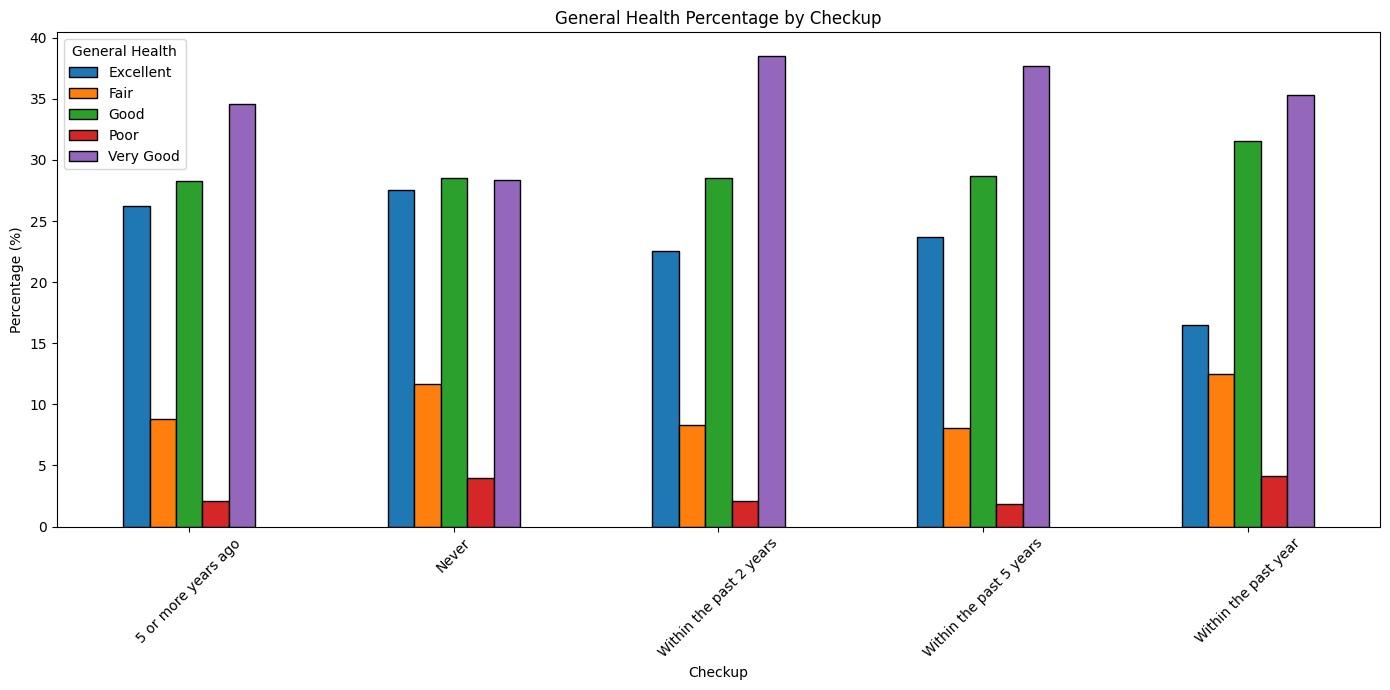

In [20]:
check_gen_ct.plot(
    kind='bar',
    figsize=(14, 7),
    edgecolor='black',
    stacked = False
)

plt.title('General Health Percentage by Checkup')
plt.xlabel('Checkup')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45)
plt.legend(title='General Health')
plt.tight_layout()
plt.show()

# The chart above shows that :
**Respondents who rate their health as `Poor` are also the most likely to report never having had a checkup, or to have gone 5+ years without one, compared to those in better health — suggesting a possible healthcare-access gap for the group that likely needs monitoring the most.**


# Section C: Body Metrics vs Heart Disease

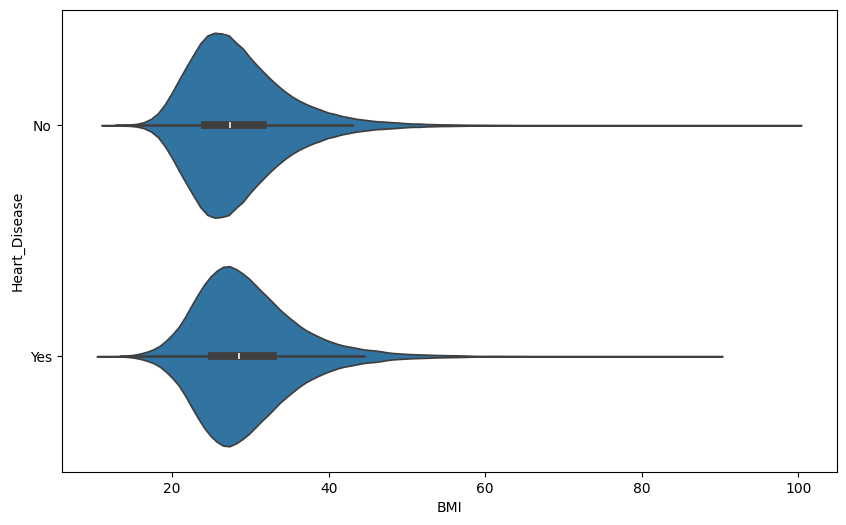

In [21]:
plt.figure(figsize=(10, 6))
sns.violinplot(x = cvd.BMI, y = cvd.Heart_Disease)
plt.show()

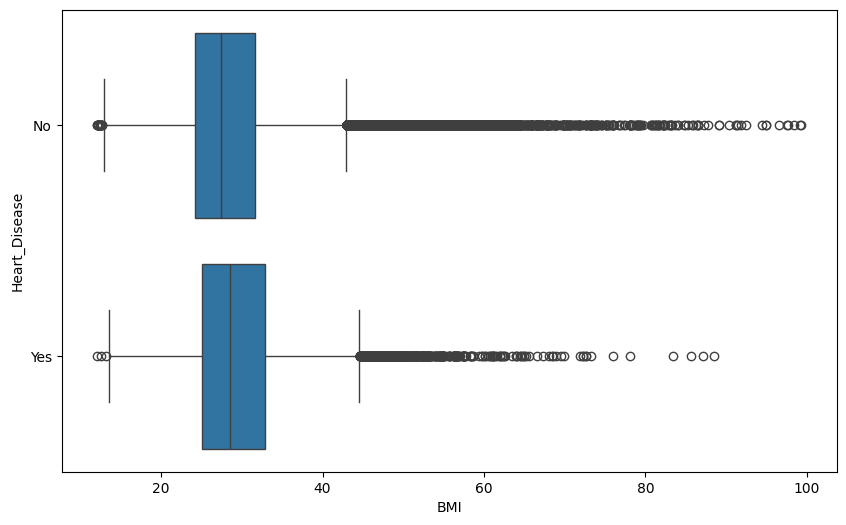

In [22]:
plt.figure(figsize=(10, 6))
sns.boxplot(x = cvd.BMI, y = cvd.Heart_Disease)
plt.show()

# The chart above shows that :
**Respondents with heart disease tend to have a higher median BMI and a wider spread toward higher BMI values than those without, though the two distributions overlap substantially — BMI alone is not a clean separator between the groups.**


### BMI Binned into Categories vs Heart Disease Rate
Standard clinical BMI bands: Underweight (<18.5), Normal (18.5-24.9), Overweight (25-29.9), Obese (30+). Checks for a threshold effect rather than a smooth trend.

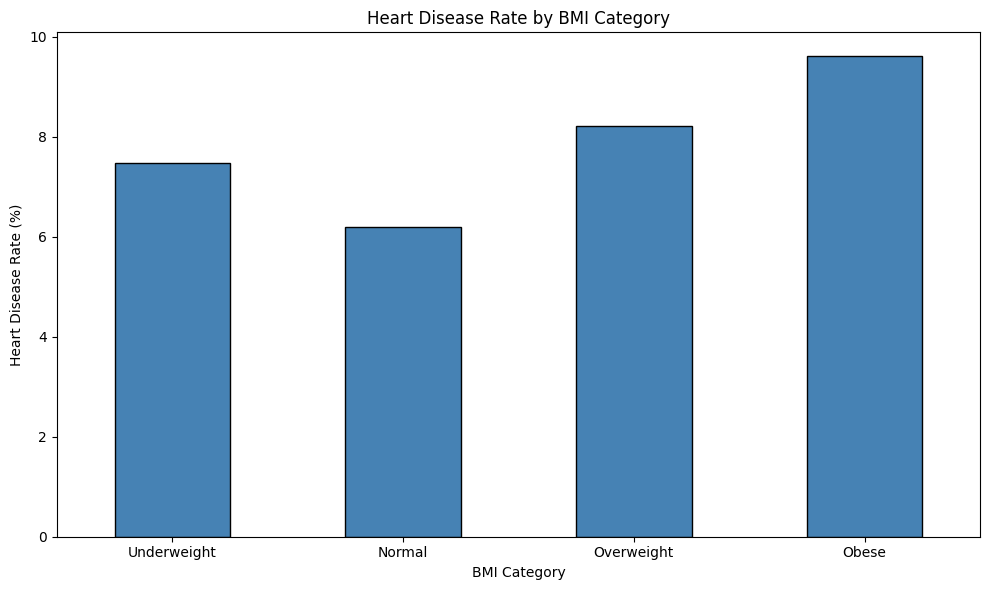

In [23]:
bmi_bins = [0, 18.5, 25, 30, cvd['BMI'].max() + 1]
bmi_labels = ['Underweight', 'Normal', 'Overweight', 'Obese']

cvd['BMI_Category'] = pd.cut(cvd['BMI'], bins=bmi_bins, labels=bmi_labels)

bmi_cat_rate = (
    cvd.groupby('BMI_Category', observed=True)['Heart_Disease']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .round(2)
    .reindex(bmi_labels)
)

bmi_cat_rate.plot(
    kind='bar',
    figsize=(10, 6),
    edgecolor='black',
    color='steelblue'
)

plt.title('Heart Disease Rate by BMI Category')
plt.xlabel('BMI Category')
plt.ylabel('Heart Disease Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# The chart above shows that :
**Heart disease rate increases with BMI category, from lowest among `Underweight`/`Normal` respondents to highest among `Obese` respondents — consistent with obesity as a known cardiovascular risk factor, though the rise is gradual rather than a sharp threshold.**


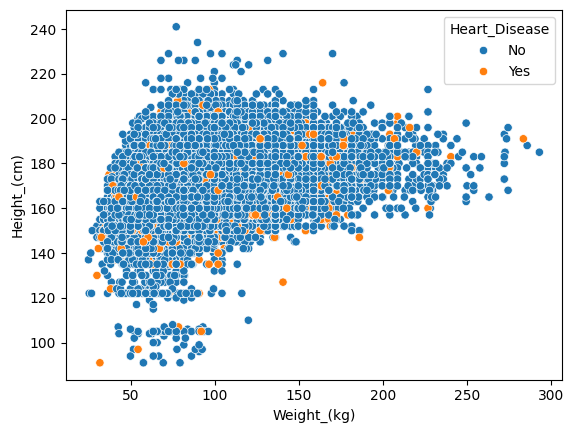

In [24]:
sns.scatterplot(x= cvd['Weight_(kg)'],y= cvd['Height_(cm)'], hue = cvd.Heart_Disease)
plt.show()

# The chart above shows that :
**Heart disease cases are spread across the full range of heights and weights with no clear visual cluster by body size alone — Height and Weight individually are weak separators, and their combined signal (captured by BMI) carries more information than either alone.**


# Section D: Lifestyle Factors vs Heart Disease

In [25]:
heart_exercise_ct = pd.crosstab(
    cvd.Heart_Disease,
    cvd.Exercise,
    normalize='index'
) * 100

heart_exercise_ct = heart_exercise_ct.round(2)

heart_exercise_ct

Exercise,No,Yes
Heart_Disease,,
No,21.30,78.70
Yes,36.06,63.94


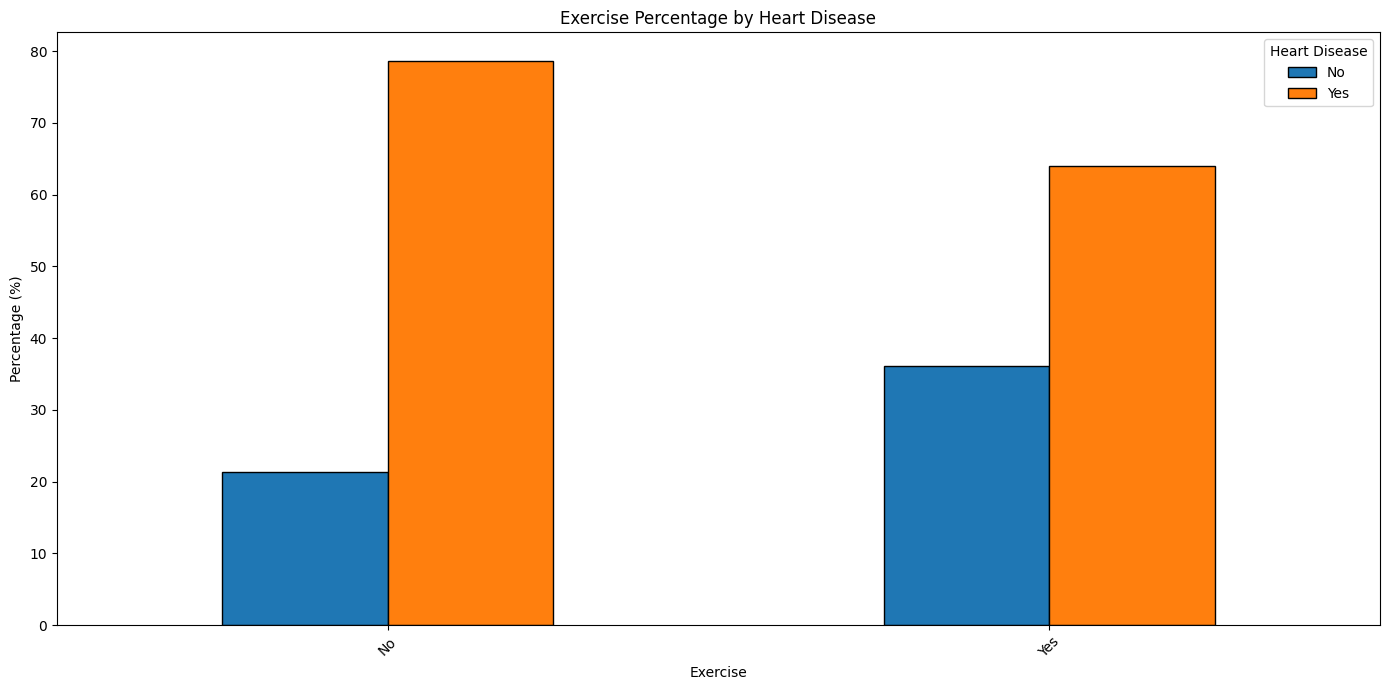

In [26]:
heart_exercise_ct.plot(
    kind='bar',
    figsize=(14, 7),
    edgecolor='black',
    stacked = False
)

plt.title('Exercise Percentage by Heart Disease')
plt.xlabel('Exercise')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45)
plt.legend(title='Heart Disease')
plt.tight_layout()
plt.show()

# The chart above shows that :
**Exercise is protective — respondents without heart disease report exercising at a noticeably higher rate (78.7%) than those with heart disease (63.9%), a roughly 15 percentage point gap.**


In [27]:
smoke_heart_ct = pd.crosstab(
    cvd.Heart_Disease,
    cvd.Smoking_History,
    normalize='index'
) * 100

smoke_heart_ct = smoke_heart_ct.round(2)

smoke_heart_ct

Smoking_History,No,Yes
Heart_Disease,,
No,61.01,38.99
Yes,41.60,58.40


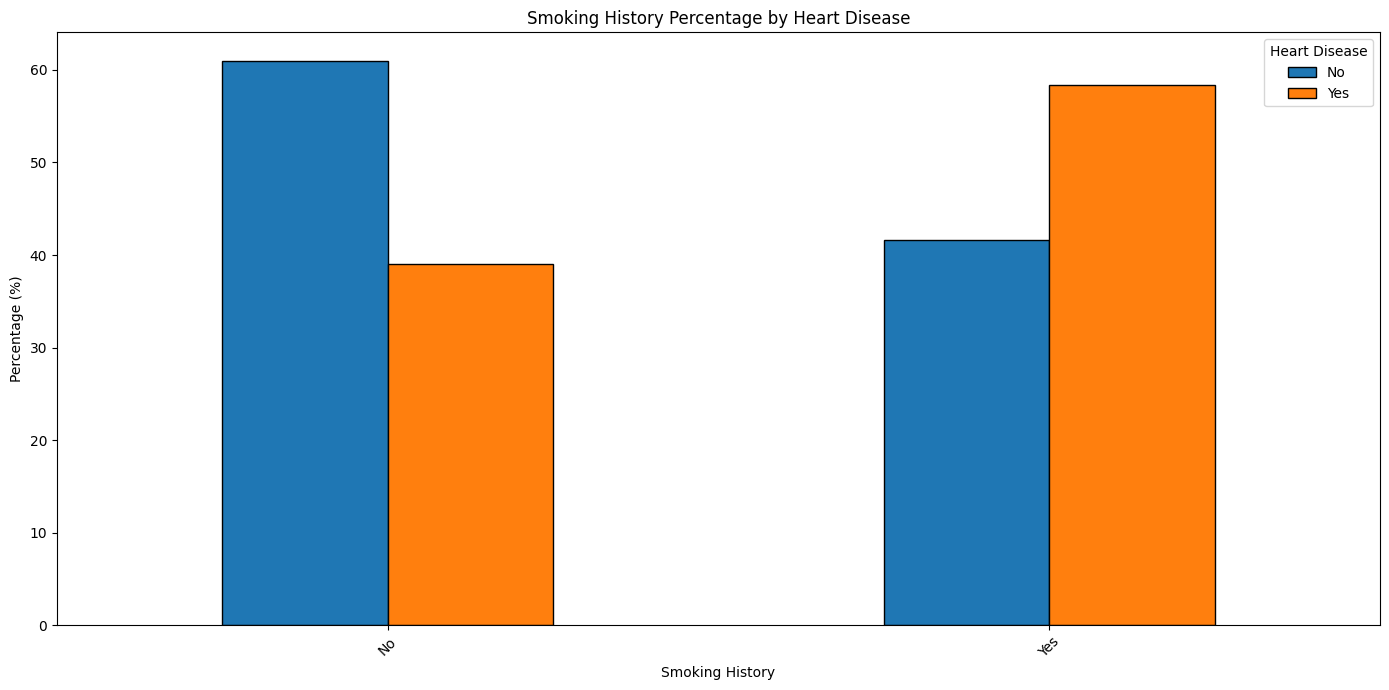

In [28]:
smoke_heart_ct.plot(
    kind='bar',
    figsize=(14, 7),
    edgecolor='black',
    stacked = False
)

plt.title('Smoking History Percentage by Heart Disease')
plt.xlabel('Smoking History')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45)
plt.legend(title='Heart Disease')
plt.tight_layout()
plt.show()

# The chart above shows that :
**Smoking history is associated with heart disease — 58.4% of respondents with heart disease report a smoking history versus 39.0% of those without, nearly a 20 percentage point gap.**


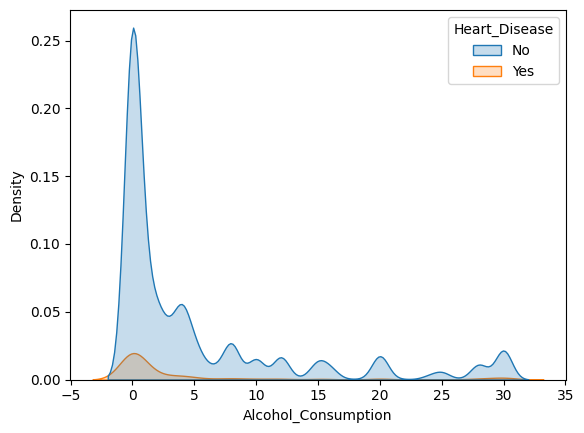

In [29]:
sns.kdeplot(data=cvd, x="Alcohol_Consumption", hue="Heart_Disease", fill=True)
plt.show()

# The chart above shows that :
**The alcohol consumption distributions for the two groups largely overlap, both concentrated at low consumption levels — alcohol consumption alone does not visually separate the groups as cleanly as exercise or smoking do.**


### Fried Potato Consumption by Heart Disease

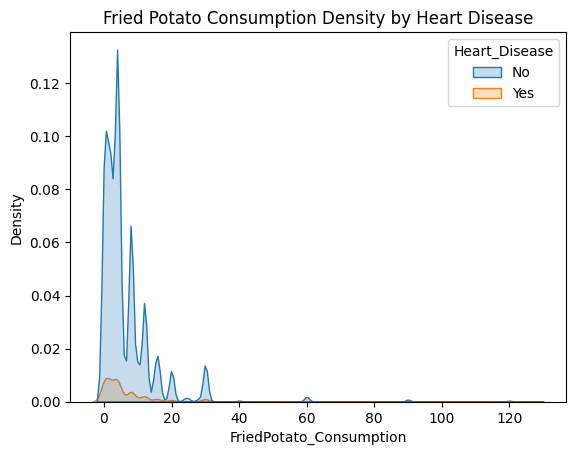

In [30]:
sns.kdeplot(data=cvd, x="FriedPotato_Consumption", hue="Heart_Disease", fill=True)
plt.title('Fried Potato Consumption Density by Heart Disease')
plt.show()

# The chart above shows that :
**Fried potato consumption is similarly distributed between respondents with and without heart disease, suggesting it is a weaker individual predictor on its own compared to exercise, smoking, or general health.**


### Green Vegetable Consumption by Heart Disease

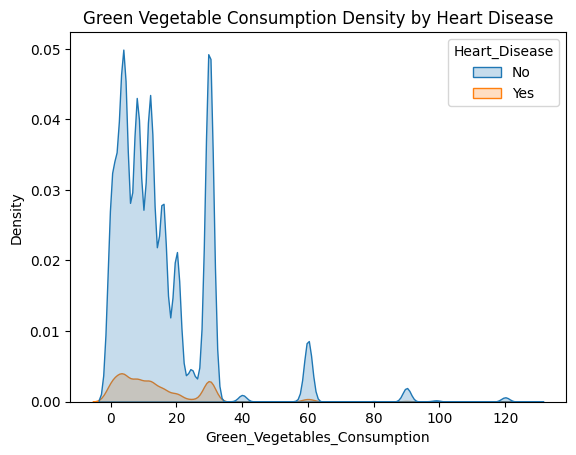

In [31]:
sns.kdeplot(data=cvd, x="Green_Vegetables_Consumption", hue="Heart_Disease", fill=True)
plt.title('Green Vegetable Consumption Density by Heart Disease')
plt.show()

# The chart above shows that :
**Green vegetable consumption is slightly higher on average for respondents without heart disease, though the two distributions overlap considerably — a modest rather than a strong protective association.**

# Section E: Comorbidities vs Heart Disease

### Diabetes vs Heart Disease

In [32]:
diabetes_heart_ct = pd.crosstab(
    cvd.Diabetes,
    cvd.Heart_Disease,
    normalize='index'
) * 100

diabetes_heart_ct = diabetes_heart_ct.round(2)

diabetes_heart_ct

Heart_Disease,No,Yes
Diabetes,,
No,93.94,6.06
"No, pre-diabetes or borderline diabetes",88.49,11.51
Yes,79.15,20.85
"Yes, but female told only during pregnancy",96.37,3.63


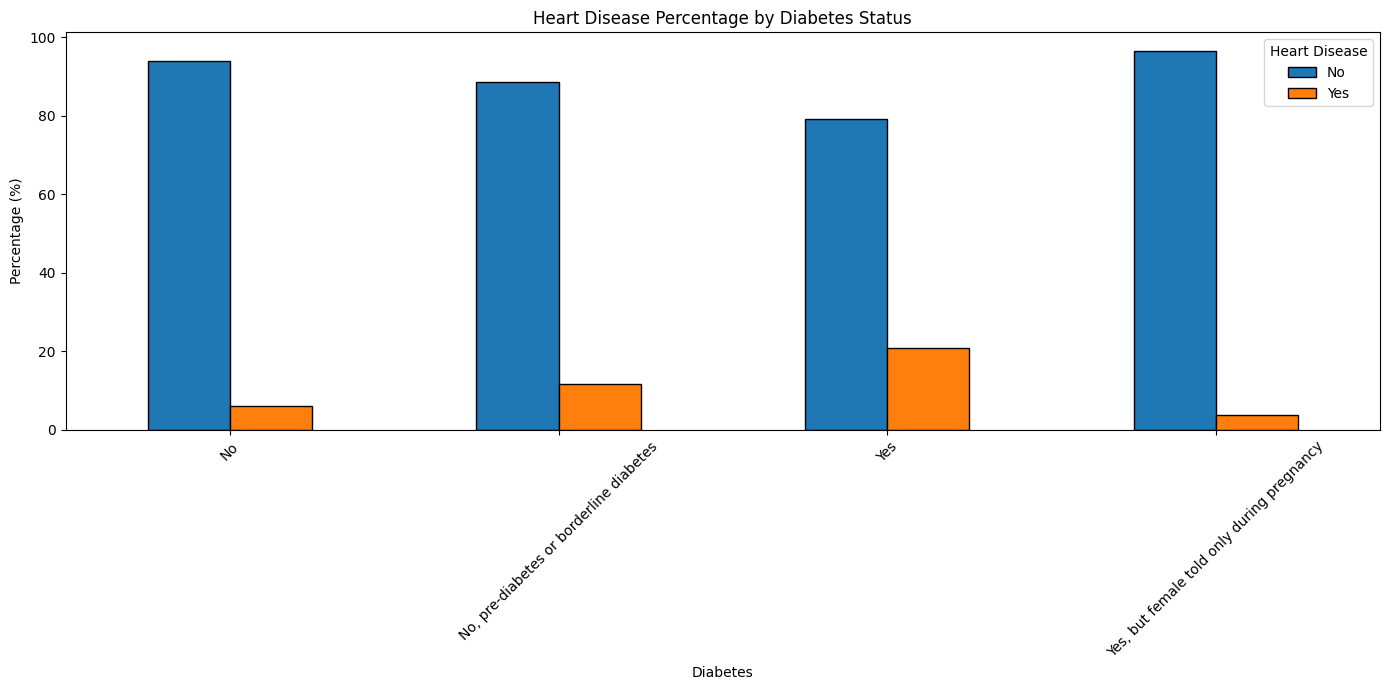

In [33]:
diabetes_heart_ct.plot(
    kind='bar',
    figsize=(14, 7),
    edgecolor='black',
    stacked=False
)

plt.title('Heart Disease Percentage by Diabetes Status')
plt.xlabel('Diabetes')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45)
plt.legend(title='Heart Disease')
plt.tight_layout()
plt.show()

# The chart above shows that :
**Heart disease rate rises sharply with diabetes severity — from 6.1% among those with no diabetes, to 11.5% for pre-diabetes/borderline cases, to 20.9% for confirmed diabetes — while the gestational-only group (3.6%) sits even lower than the no-diabetes baseline, confirming gestational diabetes is not on the same risk continuum as persistent diabetes.**


### Arthritis vs Heart Disease

In [34]:
arthritis_heart_ct = pd.crosstab(
    cvd.Arthritis,
    cvd.Heart_Disease,
    normalize='index'
) * 100

arthritis_heart_ct = arthritis_heart_ct.round(2)

arthritis_heart_ct

Heart_Disease,No,Yes
Arthritis,,
No,94.84,5.16
Yes,85.90,14.10


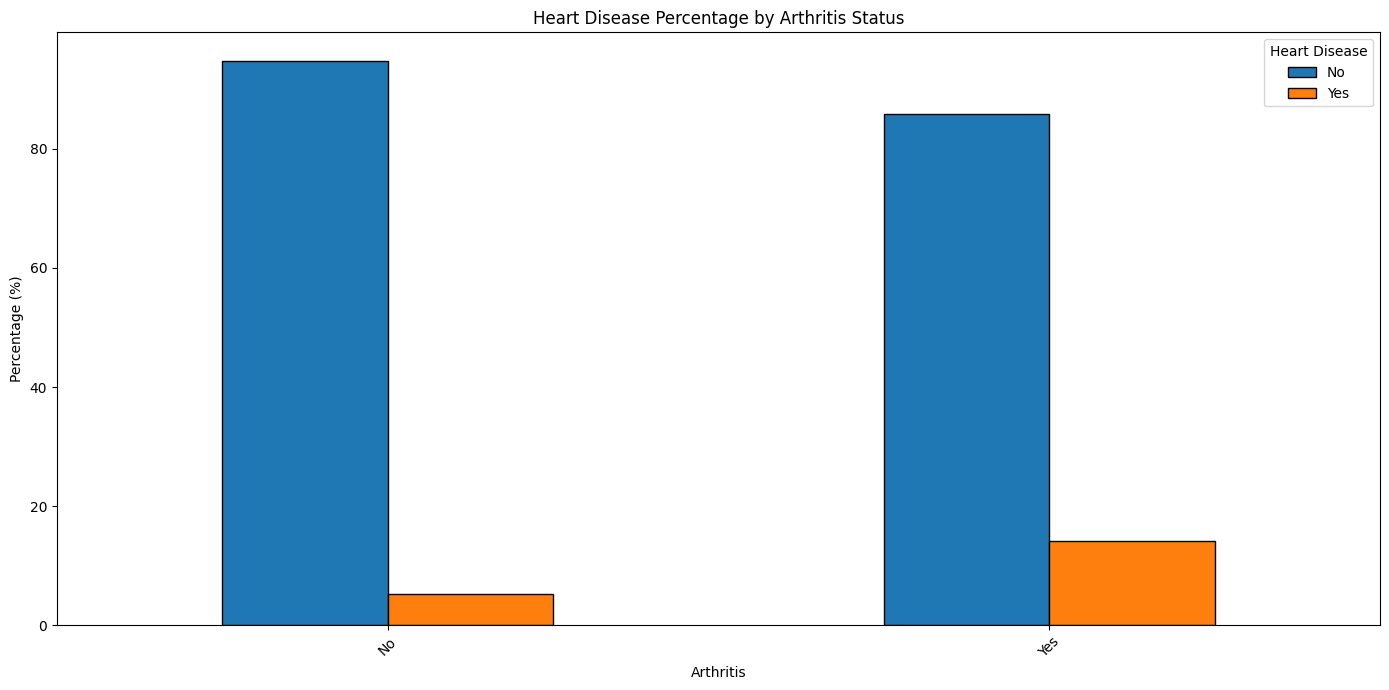

In [35]:
arthritis_heart_ct.plot(
    kind='bar',
    figsize=(14, 7),
    edgecolor='black',
    stacked=False
)

plt.title('Heart Disease Percentage by Arthritis Status')
plt.xlabel('Arthritis')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45)
plt.legend(title='Heart Disease')
plt.tight_layout()
plt.show()

# The chart above shows that :
**Heart disease rate is roughly 2.7x higher among respondents with arthritis (14.1%) than without (5.2%), consistent with shared inflammatory and aging-related pathways between the two conditions.**


### Depression vs Heart Disease

In [36]:
depression_heart_ct = pd.crosstab(
    cvd.Depression,
    cvd.Heart_Disease,
    normalize='index'
) * 100

depression_heart_ct = depression_heart_ct.round(2)

depression_heart_ct


Heart_Disease,No,Yes
Depression,,
No,92.36,7.64
Yes,90.14,9.86


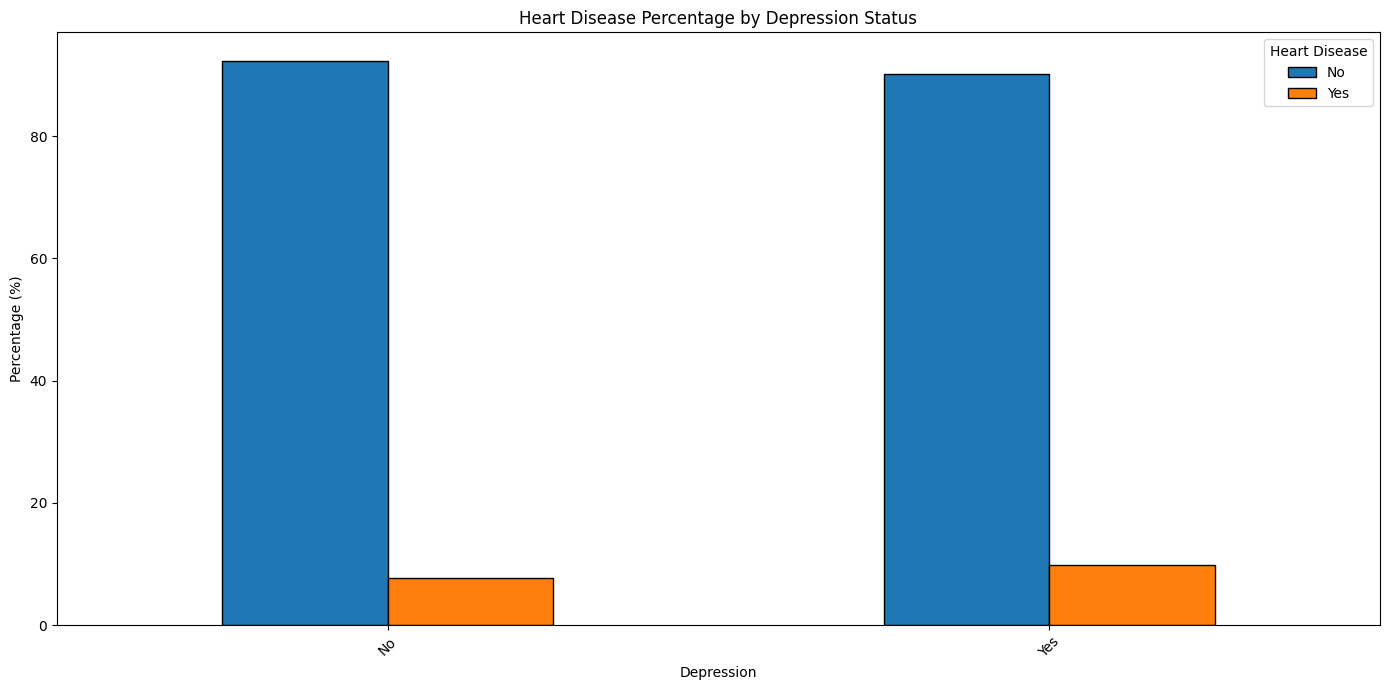

In [37]:
depression_heart_ct.plot(
    kind='bar',
    figsize=(14, 7),
    edgecolor='black',
    stacked=False
)

plt.title('Heart Disease Percentage by Depression Status')
plt.xlabel('Depression')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45)
plt.legend(title='Heart Disease')
plt.tight_layout()
plt.show()


# The chart above shows that :
**There is a modest association between depression and heart disease — 9.9% of respondents with depression report heart disease compared to 7.6% without, a smaller gap than most other comorbidities examined here.**


### Skin Cancer vs Heart Disease

In [38]:
skin_cancer_heart_ct = pd.crosstab(
    cvd.Skin_Cancer,
    cvd.Heart_Disease,
    normalize='index'
) * 100

skin_cancer_heart_ct = skin_cancer_heart_ct.round(2)

skin_cancer_heart_ct

Heart_Disease,No,Yes
Skin_Cancer,,
No,92.73,7.27
Yes,84.36,15.64


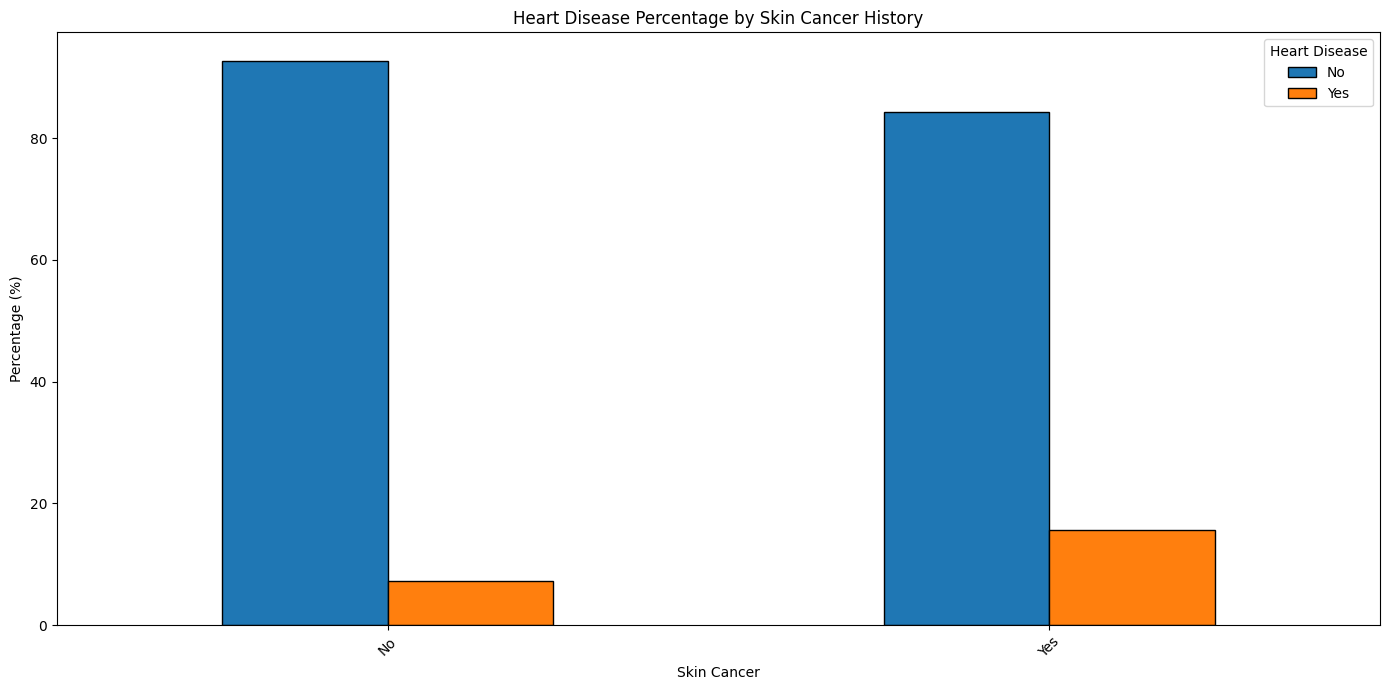

In [39]:
skin_cancer_heart_ct.plot(
    kind='bar',
    figsize=(14, 7),
    edgecolor='black',
    stacked=False
)

plt.title('Heart Disease Percentage by Skin Cancer History')
plt.xlabel('Skin Cancer')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45)
plt.legend(title='Heart Disease')
plt.tight_layout()
plt.show()

# The chart above shows that :
**Heart disease rate is roughly double among respondents with a history of skin cancer (15.6%) versus those without (7.3%), most plausibly explained by shared age-related risk rather than a direct causal link.**


### Other Cancer vs Heart Disease

In [40]:
other_cancer_heart_ct = pd.crosstab(
    cvd.Other_Cancer,
    cvd.Heart_Disease,
    normalize='index'
) * 100

other_cancer_heart_ct = other_cancer_heart_ct.round(2)

other_cancer_heart_ct


Heart_Disease,No,Yes
Other_Cancer,,
No,92.74,7.26
Yes,84.22,15.78


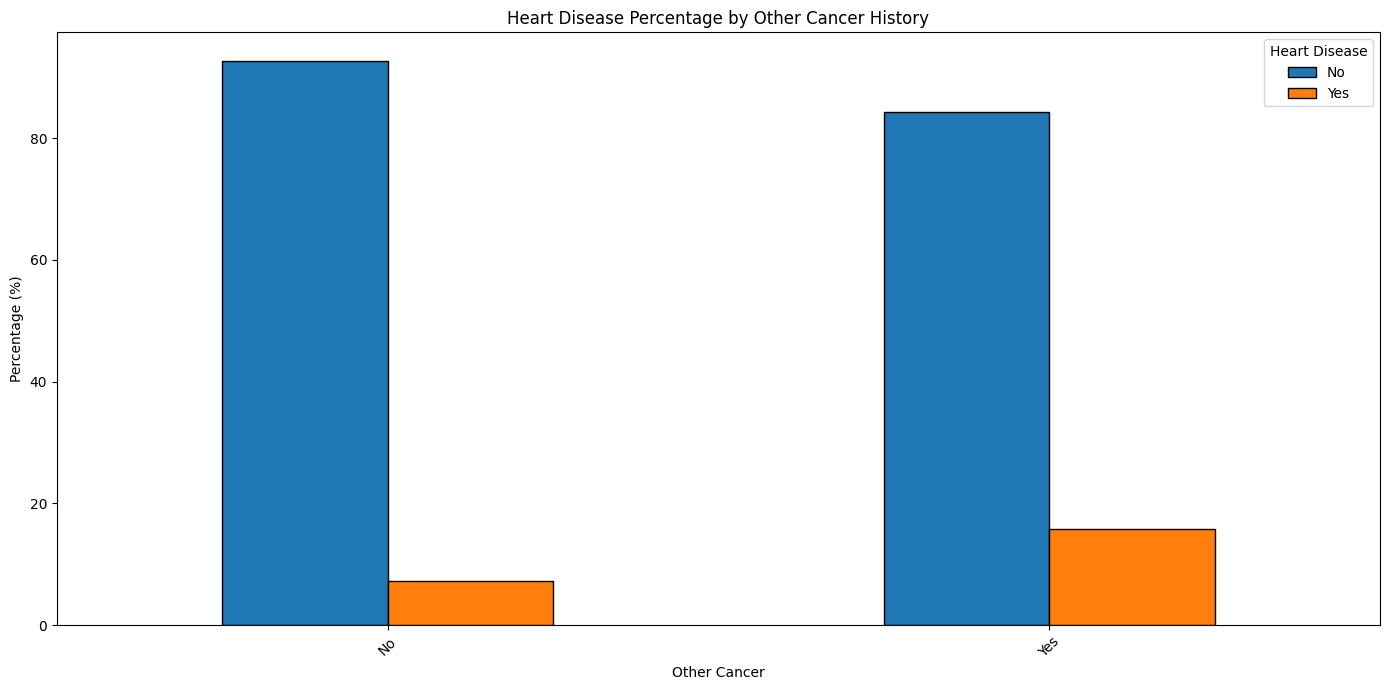

In [41]:
other_cancer_heart_ct.plot(
    kind='bar',
    figsize=(14, 7),
    edgecolor='black',
    stacked=False
)

plt.title('Heart Disease Percentage by Other Cancer History')
plt.xlabel('Other Cancer')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45)
plt.legend(title='Heart Disease')
plt.tight_layout()
plt.show()


# The chart above shows that :
**A similar pattern appears for other cancers — respondents with a history of other cancers have a heart disease rate of 15.8% versus 7.3% without, again best explained by shared age-related risk rather than cancer directly causing heart disease.**


### Engineered Feature: Comorbidity Count vs Heart Disease Rate
Sums the Yes-flags across Diabetes, Arthritis, Depression, Skin_Cancer, and Other_Cancer to get a cumulative comorbidity burden per respondent.

In [42]:
comorbidity_cols = ['Diabetes', 'Arthritis', 'Depression', 'Skin_Cancer', 'Other_Cancer']

cvd['Comorbidity_Count'] = sum(
    (cvd[col] == 'Yes').astype(int) for col in comorbidity_cols
)

cvd['Comorbidity_Count'].value_counts().sort_index()


Comorbidity_Count
0    137992
1    101377
2     50137
3     16280
4      2816
5       252
Name: count, dtype: int64

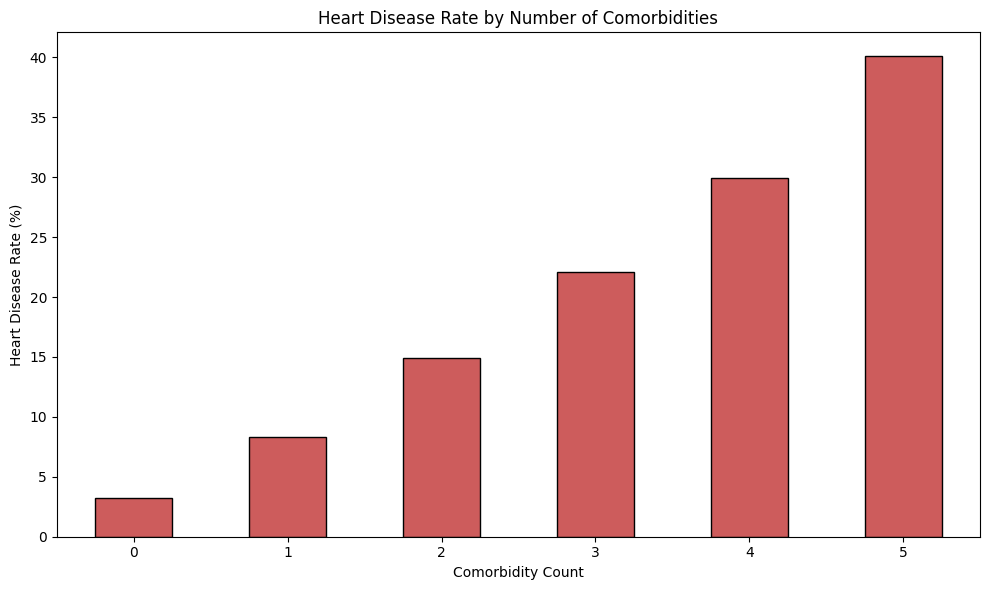

In [43]:
comorbidity_rate = (
    cvd.groupby('Comorbidity_Count')['Heart_Disease']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .round(2)
)

comorbidity_rate.plot(
    kind='bar',
    figsize=(10, 6),
    edgecolor='black',
    color='indianred'
)

plt.title('Heart Disease Rate by Number of Comorbidities')
plt.xlabel('Comorbidity Count')
plt.ylabel('Heart Disease Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# The chart above shows that :
**Heart disease rate climbs steadily with the number of comorbidities present, from a low baseline among respondents with zero flagged conditions up through those with 4-5 — cardiovascular risk compounds as additional health conditions stack up, making `Comorbidity_Count` a potentially valuable engineered feature for modeling.**


# Section F: Feature Relationships (Multicollinearity Checks)

### Correlation Heatmap of Numeric Features

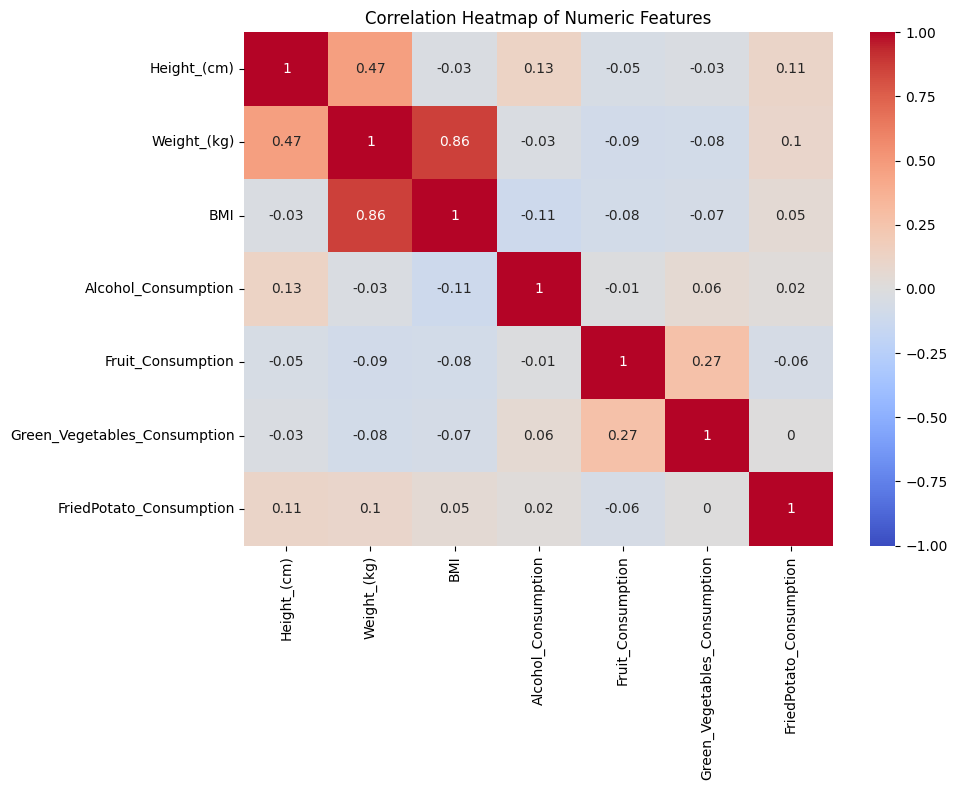

In [44]:
numeric_cols = [
    'Height_(cm)', 'Weight_(kg)', 'BMI',
    'Alcohol_Consumption', 'Fruit_Consumption',
    'Green_Vegetables_Consumption', 'FriedPotato_Consumption'
]

corr_matrix = cvd[numeric_cols].corr().round(2)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.show()

# The chart above shows that :
**Height and Weight are both strongly correlated with BMI, as expected since BMI is calculated directly from them, while the four consumption variables (Alcohol, Fruit, Green Vegetables, Fried Potato) show only weak correlations with each other and with body-size measures — limited multicollinearity risk from the lifestyle variables, but Height/Weight/BMI redundancy should be addressed before modeling.**


# Section G: Data Quality / Structural EDA

In [45]:
cvd.isnull().sum()

General_Health                  0
Checkup                         0
Exercise                        0
Heart_Disease                   0
Skin_Cancer                     0
Other_Cancer                    0
Depression                      0
Diabetes                        0
Arthritis                       0
Sex                             0
Age_Category                    0
Height_(cm)                     0
Weight_(kg)                     0
BMI                             0
Smoking_History                 0
Alcohol_Consumption             0
Fruit_Consumption               0
Green_Vegetables_Consumption    0
FriedPotato_Consumption         0
BMI_Category                    0
Comorbidity_Count               0
dtype: int64

### Outlier Check: Boxplot Grid for Numeric Columns

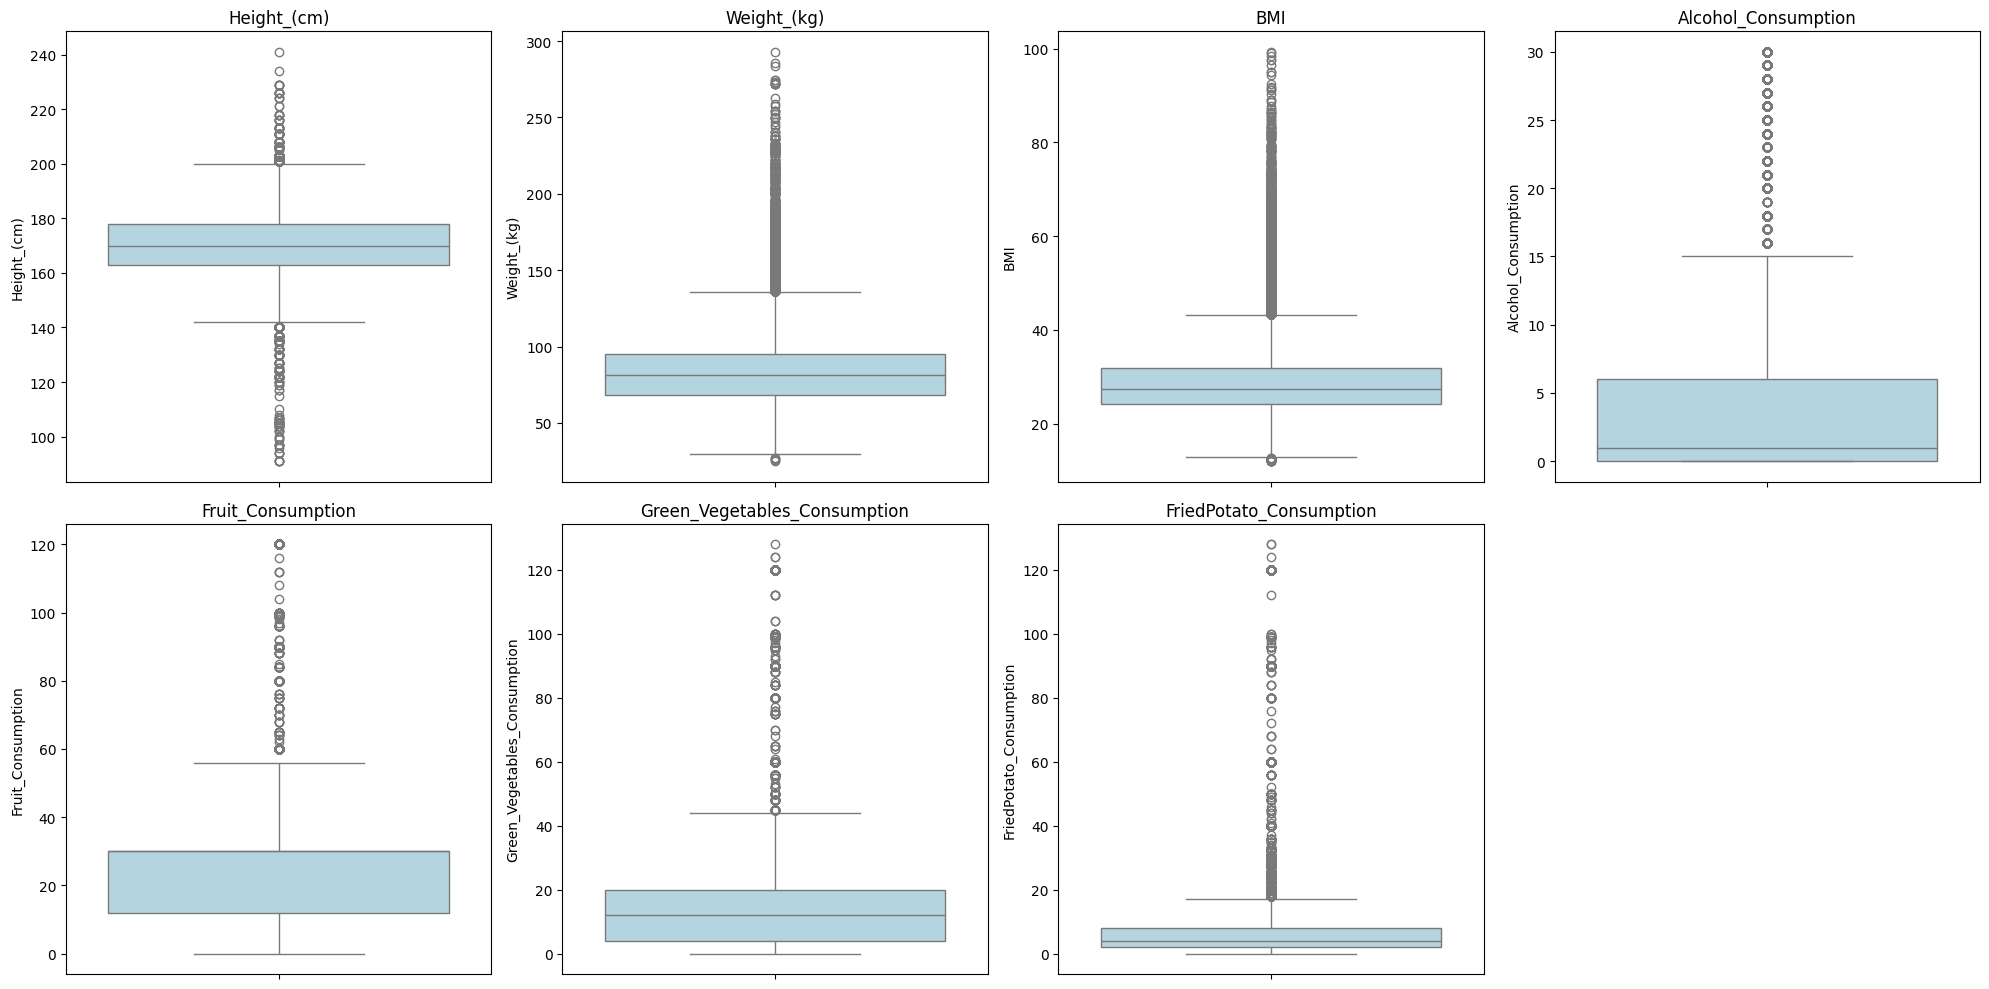

In [46]:
numeric_cols_grid = [
    'Height_(cm)', 'Weight_(kg)', 'BMI',
    'Alcohol_Consumption', 'Fruit_Consumption',
    'Green_Vegetables_Consumption', 'FriedPotato_Consumption'
]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols_grid):
    sns.boxplot(y=cvd[col], ax=axes[i], color='lightblue')
    axes[i].set_title(col)

# Hide any unused subplot axes
for j in range(len(numeric_cols_grid), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


# The chart above shows that :
**Several numeric columns — particularly Weight, BMI, and the consumption variables — show a notable number of high-end outliers extending well beyond the upper whisker, consistent with the right-skewed, self-reported nature of survey data like alcohol and fried potato consumption.**


# Section H: Engineered `Age_Mid` (Numeric Age) Feature

### Create `Age_Mid` and an ordered `Age_Category`
`Age_Mid` maps each age bin to its midpoint so age can be treated as continuous for KDE plots, trend lines, scatter plots, and correlation analysis. The `80+` bin has no natural midpoint, so it is mapped to 85 (documented assumption). `Age_Category` is also cast to an ordered categorical so it sorts correctly on plots.

In [47]:
age_order = ['18-24', '25-29', '30-34', '35-39', '40-44', '45-49',
             '50-54', '55-59', '60-64', '65-69', '70-74', '75-79', '80+']

age_map = {
    '18-24': 21, '25-29': 27, '30-34': 32, '35-39': 37,
    '40-44': 42, '45-49': 47, '50-54': 52, '55-59': 57,
    '60-64': 62, '65-69': 67, '70-74': 72, '75-79': 77,
    '80+': 85
}

cvd['Age_Category'] = pd.Categorical(cvd['Age_Category'], categories=age_order, ordered=True)
cvd['Age_Mid'] = cvd['Age_Category'].map(age_map)

cvd['Heart_Disease_Num'] = (cvd['Heart_Disease'] == 'Yes').astype(int)

cvd[['Age_Category', 'Age_Mid', 'Heart_Disease', 'Heart_Disease_Num']].head()


,Age_Category,Age_Mid,Heart_Disease,Heart_Disease_Num
0,70-74,72,No,0
1,70-74,72,Yes,1
2,60-64,62,No,0
3,75-79,77,Yes,1
4,80+,85,No,0


### Age Distribution by Heart Disease (KDE Overlay)

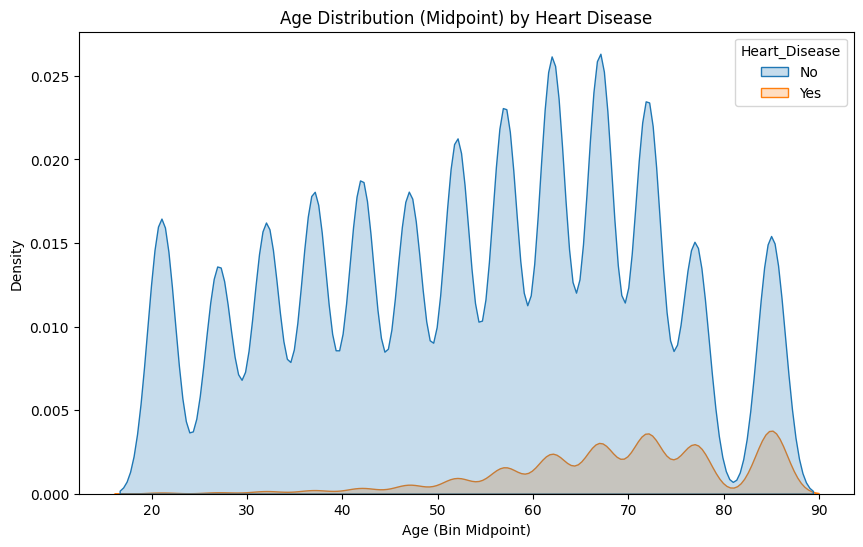

In [48]:
plt.figure(figsize=(10, 6))
cvd['Age_Mid'] = cvd['Age_Mid'].astype(float)
sns.kdeplot(data=cvd, x='Age_Mid', hue='Heart_Disease', fill=True)
plt.title('Age Distribution (Midpoint) by Heart Disease')
plt.xlabel('Age (Bin Midpoint)')
plt.show()

# The chart above shows that :
**The age distribution for respondents with heart disease is shifted noticeably toward older ages compared to those without — the `No` group is concentrated in mid-adulthood, while the `Yes` group is concentrated in the 60s-70s range.**


### Heart Disease Rate Trend Across Age (Line Plot)

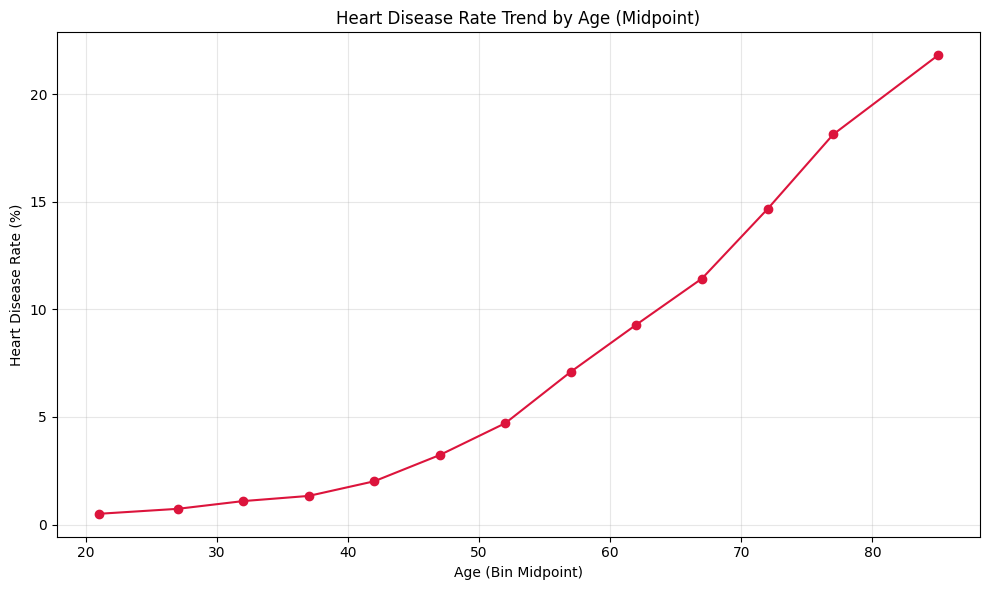

In [49]:
age_rate_trend = (
    cvd.groupby('Age_Mid')['Heart_Disease_Num']
    .mean()
    .mul(100)
    .round(2)
)

age_rate_trend.plot(kind='line', marker='o', figsize=(10, 6), color='crimson')
plt.title('Heart Disease Rate Trend by Age (Midpoint)')
plt.xlabel('Age (Bin Midpoint)')
plt.ylabel('Heart Disease Rate (%)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# The chart above shows that :
**Heart disease rate rises in a smooth, steadily accelerating curve from under 1% at the youngest age midpoint to over 20% at the oldest — confirming age as one of the strongest and most consistent risk gradients in the dataset.**


### Age vs Heart Disease with Logistic Trend Curve
Visual check of whether the log-odds of heart disease increase roughly linearly with age.

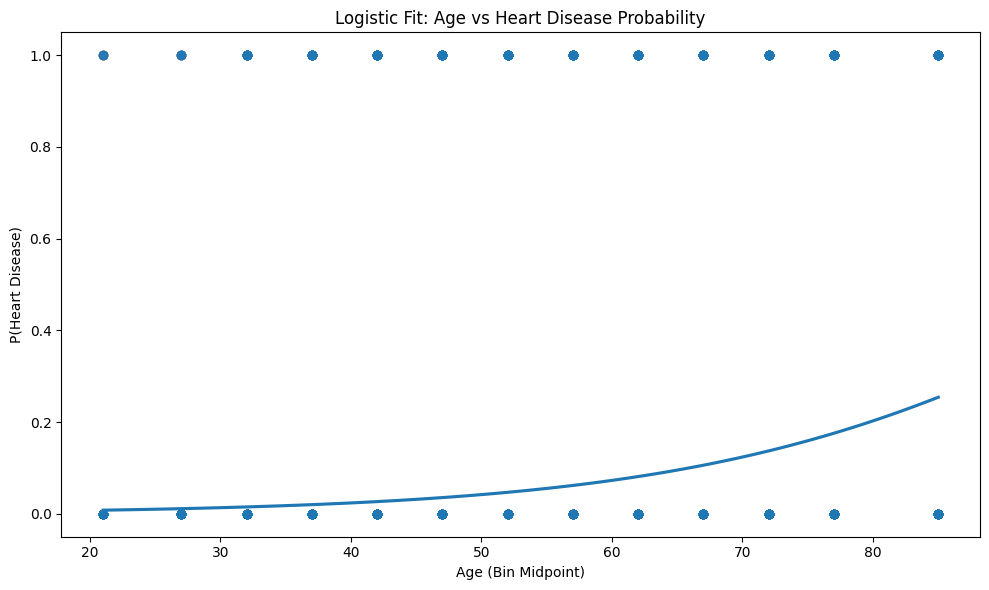

In [50]:
plt.figure(figsize=(10, 6))
sns.regplot(
    data=cvd, x='Age_Mid', y='Heart_Disease_Num',
    logistic=True, ci=None,
    scatter_kws={'alpha': 0.02}
)
plt.title('Logistic Fit: Age vs Heart Disease Probability')
plt.xlabel('Age (Bin Midpoint)')
plt.ylabel('P(Heart Disease)')
plt.tight_layout()
plt.show()

# The chart above shows that :
**The predicted probability of heart disease increases in a curve consistent with a logistic (S-shaped) relationship to age rather than a straight line, supporting age as a well-behaved numeric/ordinal feature for both linear and tree-based models.**

### Age vs BMI, Colored by Heart Disease

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


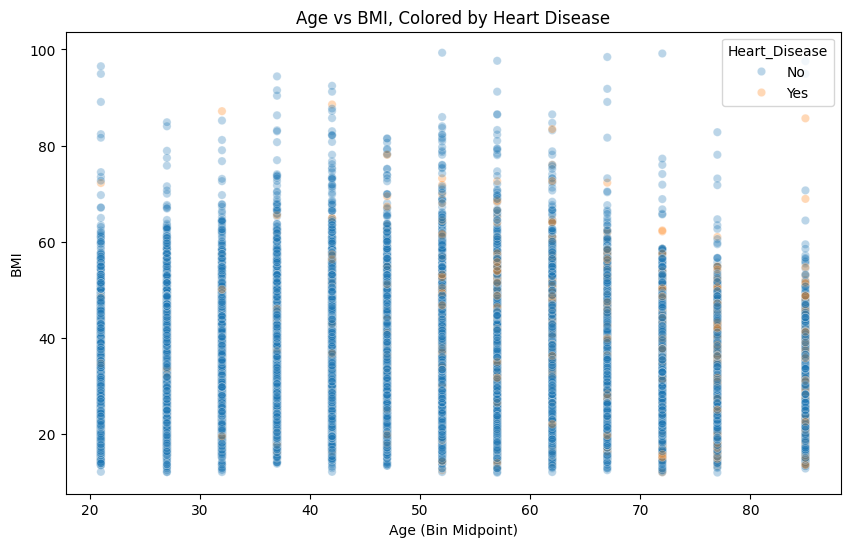

In [51]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=cvd, x='Age_Mid', y='BMI', hue='Heart_Disease', alpha=0.3)
plt.title('Age vs BMI, Colored by Heart Disease')
plt.xlabel('Age (Bin Midpoint)')
plt.ylabel('BMI')
plt.show()

# The chart above shows that :
**Heart disease cases are concentrated toward the older, and to a lesser extent higher-BMI, region of the plot, though substantial overlap with non-cases remains across the full BMI range at every age.**


### Age vs BMI vs Heart Disease, Faceted by Sex

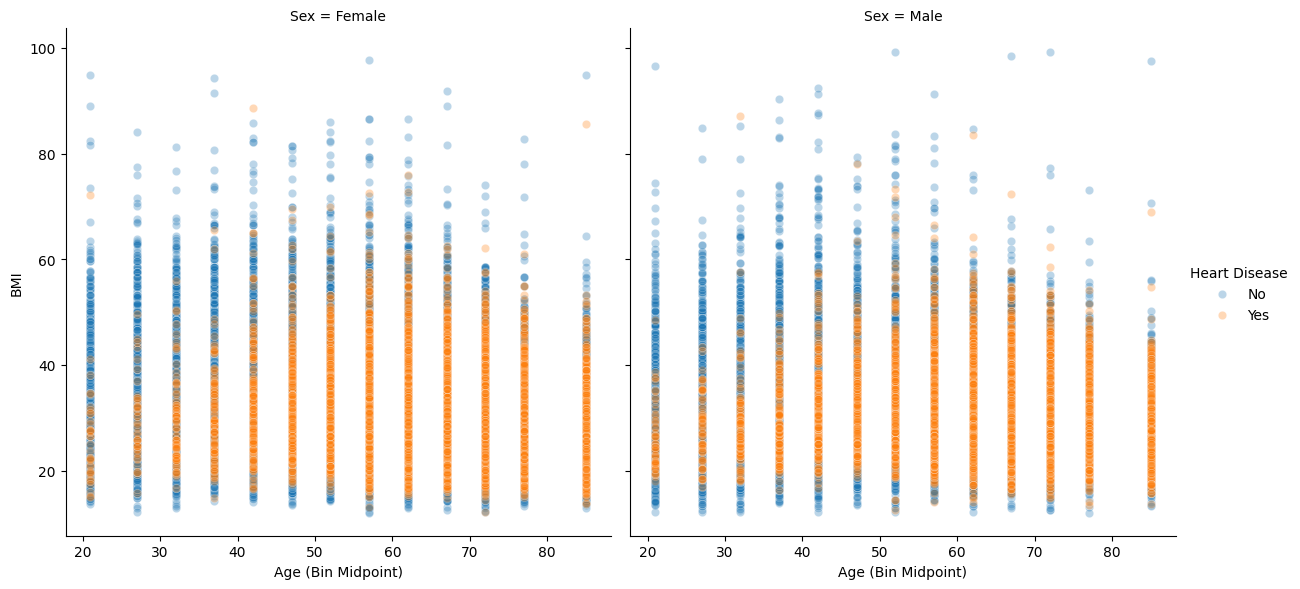

In [52]:
g = sns.FacetGrid(cvd, col='Sex', hue='Heart_Disease', height=6, aspect=1)
g.map(sns.scatterplot, 'Age_Mid', 'BMI', alpha=0.3)
g.add_legend(title='Heart Disease')
g.set_axis_labels('Age (Bin Midpoint)', 'BMI')
plt.show()

# The chart above shows that :
**The age-BMI pattern for heart disease holds for both sexes — cases skew older in both the Female and Male panels, with no strong sex-specific divergence in how age and BMI jointly relate to risk.**


### Average Age by Heart Disease Status

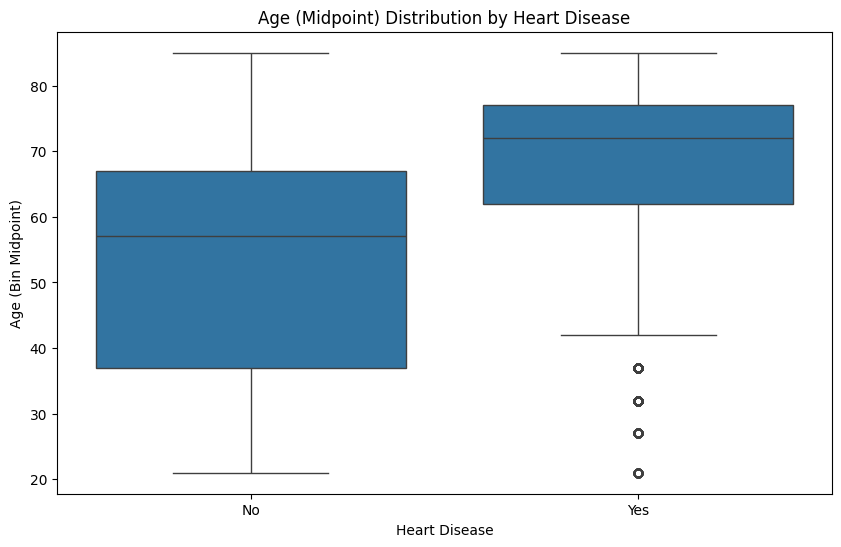

In [53]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=cvd.Heart_Disease, y=cvd.Age_Mid)
plt.title('Age (Midpoint) Distribution by Heart Disease')
plt.xlabel('Heart Disease')
plt.ylabel('Age (Bin Midpoint)')
plt.show()

# The chart above shows that :
**The median age midpoint is clearly higher for respondents with heart disease than without, with less overlap between the two groups' interquartile ranges than most other numeric features examined — reinforcing age as one of the cleanest single separators in the dataset.**


### Correlation Heatmap Including Age_Mid

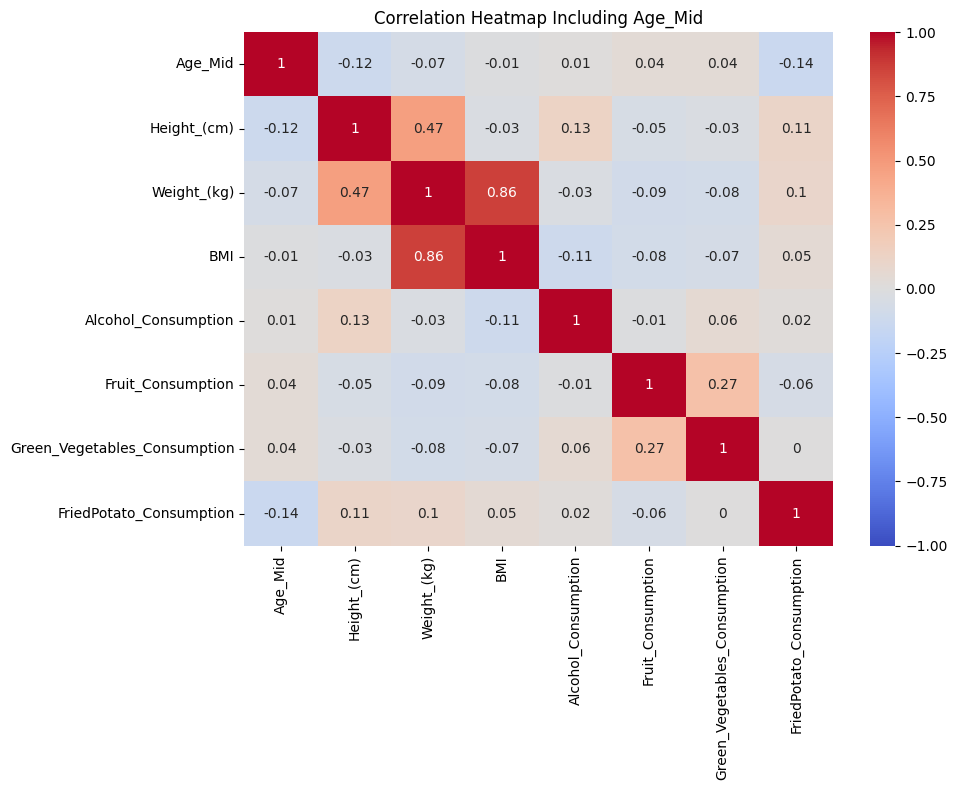

In [54]:
numeric_cols_with_age = [
    'Age_Mid', 'Height_(cm)', 'Weight_(kg)', 'BMI',
    'Alcohol_Consumption', 'Fruit_Consumption',
    'Green_Vegetables_Consumption', 'FriedPotato_Consumption'
]

corr_matrix_age = cvd[numeric_cols_with_age].corr().round(2)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix_age, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Correlation Heatmap Including Age_Mid')
plt.tight_layout()
plt.show()


# The chart above shows that :
**`Age_Mid` has only a weak-to-moderate direct correlation with the other numeric features (BMI, Height, Weight, consumption variables), suggesting age's strong relationship with heart disease risk operates largely independently of these other numeric factors rather than through them.**


### Multivariate Numeric Relationships (Pairplot)
Note: pairplots are expensive to render on the full dataset — consider sampling rows first.

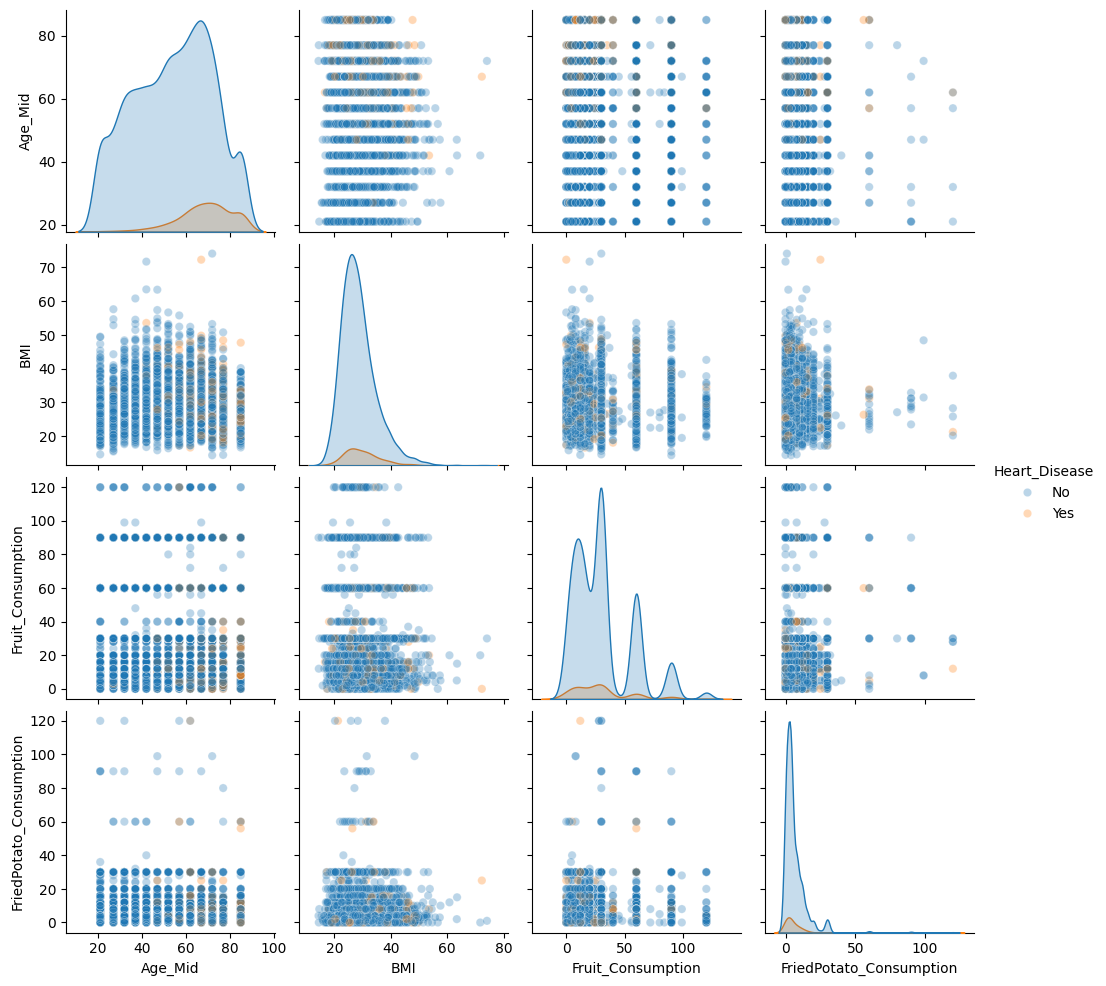

In [55]:
pairplot_cols = ['Age_Mid', 'BMI', 'Fruit_Consumption', 'FriedPotato_Consumption', 'Heart_Disease']

cvd_sample = cvd[pairplot_cols].sample(n=min(5000, len(cvd)), random_state=42)

sns.pairplot(cvd_sample, hue='Heart_Disease', diag_kind='kde', plot_kws={'alpha': 0.3})
plt.show()

# The chart above shows that :
**Heart disease cases cluster toward the older, and to a lesser degree higher-BMI, end of the sampled data across every pairwise combination, while the consumption variables (Fruit and Fried Potato) show little separation between the two groups — visually reinforcing age and BMI as the more informative numeric features among those plotted.**


## Modelling

In [56]:
age_bins = [0, 30, 40, 50, 60, 70, 100]
age_bin_labels = ['<30', '30-39', '40-49', '50-59', '60-69', '70+']

cvd['Age_Bin'] = pd.cut(cvd['Age_Mid'], bins=age_bins, labels=age_bin_labels)

In [57]:
ord_col = ["Exercise", "Skin_Cancer", "Other_Cancer", "Depression", "Arthritis", "Smoking_History"]

In [58]:
map_ord = {
    'Yes': 1,
    'No': 0
}
for col in ord_col:
  cvd[col] =cvd[col].map(map_ord)

In [59]:
Gen_map = {
    "Poor": 0,
    "Fair": 1,
    "Good": 2,
    "Very Good": 3,
    "Excellent": 4
}
cvd["General_Health"] = cvd["General_Health"].map(Gen_map)

Checkup_map = {
    "Never": 0,
    "5 or more years ago": 1,
    "Within the past 5 years": 2,
    "Within the past 2 years": 3,
    "Within the past year": 4
}
cvd["Checkup"] = cvd["Checkup"].map(Checkup_map)

Age_Category_map = {
    "18-24": 0, "25-29": 1, "30-34": 2, "35-39": 3, "40-44": 4,
    "45-49": 5, "50-54": 6, "55-59": 7, "60-64": 8, "65-69": 9,
    "70-74": 10, "75-79": 11, "80+": 12
}
cvd["Age_Category"] = cvd["Age_Category"].map(Age_Category_map)

BMI_Category_map = {
    "Underweight": 0,
    "Normal": 1,
    "Overweight": 2,
    "Obese": 3
}
cvd["BMI_Category"] = cvd["BMI_Category"].map(BMI_Category_map)

Age_Bin_map = {
    "<30": 0,
    "30-39": 1,
    "40-49": 2,
    "50-59": 3,
    "60-69": 4,
    "70+": 5
}
cvd["Age_Bin"] = cvd["Age_Bin"].map(Age_Bin_map)

Sex_map = {
    "Female": 0,
    "Male": 1
}
cvd["Sex"] = cvd["Sex"].map(Sex_map)

In [60]:
diabetes_dummies = pd.get_dummies(cvd["Diabetes"], prefix="Diabetes", drop_first=True, dtype=int)

cvd = pd.concat([cvd, diabetes_dummies], axis=1)

cvd.drop(columns=["Diabetes"], inplace=True)

cvd.head()

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Arthritis,Sex,Age_Category,...,Green_Vegetables_Consumption,FriedPotato_Consumption,BMI_Category,Comorbidity_Count,Age_Mid,Heart_Disease_Num,Age_Bin,"Diabetes_No, pre-diabetes or borderline diabetes",Diabetes_Yes,"Diabetes_Yes, but female told only during pregnancy"
0,0,3,0,No,0,0,0,1,0,10,...,16.0,12.0,0,1,72.0,0,5,0,0,0
1,3,4,0,Yes,0,0,0,0,0,10,...,0.0,4.0,2,1,72.0,1,5,0,1,0
2,3,4,1,No,0,0,0,0,0,8,...,3.0,16.0,3,1,62.0,0,4,0,1,0
3,0,4,1,Yes,0,0,0,0,1,11,...,30.0,8.0,2,1,77.0,1,5,0,1,0
4,2,4,0,No,0,0,0,0,1,12,...,4.0,0.0,1,0,85.0,0,5,0,0,0


In [61]:
le = LabelEncoder()
cvd["Heart_Disease"] = le.fit_transform(cvd["Heart_Disease"])

In [62]:
X = cvd.drop(columns=["Heart_Disease", "Heart_Disease_Num"])
y = cvd["Heart_Disease"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [63]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# **Model Evaluation**

In [64]:
def objective(trial):

    k_neighbors = trial.suggest_int("smote_k_neighbors", 3, 10)
    sampler_step = SMOTE(k_neighbors=k_neighbors, random_state=22)

    classifier_name = trial.suggest_categorical(
        "classifier_name",
        ["LGBMClassifier", "HistGradientBoostingClassifier"]
    )

    if classifier_name == "LGBMClassifier":
        n_estimators = trial.suggest_int("lgbm_n_estimators", 100, 400)
        learning_rate = trial.suggest_float("lgbm_learning_rate", 0.01, 0.3, log=True)
        max_depth = trial.suggest_int("lgbm_max_depth", 3, 12)
        num_leaves = trial.suggest_int("lgbm_num_leaves", 15, 100)
        min_child_samples = trial.suggest_int("lgbm_min_child_samples", 5, 100)
        model = LGBMClassifier(
            n_estimators=n_estimators, learning_rate=learning_rate,
            max_depth=max_depth, num_leaves=num_leaves,
            min_child_samples=min_child_samples,
            n_jobs=-1, random_state=22, verbose=-1
        )

    elif classifier_name == "HistGradientBoostingClassifier":
        learning_rate = trial.suggest_float("hgb_learning_rate", 0.01, 0.3, log=True)
        max_iter = trial.suggest_int("hgb_max_iter", 100, 500)
        max_depth = trial.suggest_int("hgb_max_depth", 3, 12)
        min_samples_leaf = trial.suggest_int("hgb_min_samples_leaf", 5, 50)
        l2_regularization = trial.suggest_float("hgb_l2_regularization", 0.0, 1.0)
        model = HistGradientBoostingClassifier(
            learning_rate=learning_rate, max_iter=max_iter, max_depth=max_depth,
            min_samples_leaf=min_samples_leaf, l2_regularization=l2_regularization,
            random_state=22
        )

    pipeline = ImbPipeline([
        ("sampler", sampler_step),
        ("model", model),
    ])

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=22)
    scores = cross_val_score(
        pipeline, X_train_scaled, y_train,
        cv=cv, scoring="average_precision", n_jobs=1, error_score="raise"
    )

    return scores.mean()

study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=22),
    study_name="cvd_smote_model_search_fast"
)

start = time.time()
study.optimize(objective, n_trials=50, timeout=2700, show_progress_bar=True)
print(f"Search finished in {time.time() - start:.1f}s")

[I 2026-09-10 10:29:28,579] A new study created in memory with name: cvd_smote_model_search_fast


  0%|          | 0/50 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[I 2026-09-10 10:30:18,717] Trial 0 finished with value: 0.28535199587179677 and parameters: {'smote_k_neighbors': 4, 'classifier_name': 'LGBMClassifier', 'lgbm_n_estimators': 358, 'lgbm_learning_rate': 0.017898901119304807, 'lgbm_max_depth': 6, 'lgbm_num_leaves': 38, 'lgbm_min_child_samples': 71}. Best is trial 0 with value: 0.28535199587179677.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


...

[I 2026-09-10 11:07:14,851] Trial 46 finished with value: 0.29645063517992093 and parameters: {'smote_k_neighbors': 8, 'classifier_name': 'LGBMClassifier', 'lgbm_n_estimators': 227, 'lgbm_learning_rate': 0.07967667411934795, 'lgbm_max_depth': 10, 'lgbm_num_leaves': 43, 'lgbm_min_child_samples': 65}. Best is trial 14 with value: 0.297642968868883.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[I 2026-09-10 11:07:46,986] Trial 47 finished with value: 0.29563767076568304 and parameters: {'smote_k_neighbors': 8, 'classifier_name': 'LGBMClassifier', 'lgbm_n_estimators': 177, 'lgbm_learning_rate': 0.05085157815181986, 'lgbm_max_depth': 9, 'lgbm_num_leaves': 48, 'lgbm_min_child_samples': 57}. Best is trial 14 with value: 0.297642968868883.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[I 2026-09-10 11:08:13,946] Trial 48 finished with value: 0.2906683923555559 and parameters: {'smote_k_neighbors': 10, 'classifier_name': 'LGBMClassifier', 'lgbm_n_estimators': 206, 'lgbm_learning_rate': 0.20433046519208878, 'lgbm_max_depth': 7, 'lgbm_num_leaves': 29, 'lgbm_min_child_samples': 79}. Best is trial 14 with value: 0.297642968868883.
[I 2026-09-10 11:09:42,568] Trial 49 finished with value: 0.2897050587321349 and parameters: {'smote_k_neighbors': 7, 'classifier_name': 'HistGradientBoostingClassifier', 'hgb_learning_rate': 0.1060531207408219, 'hgb_max_iter': 420, 'hgb_max_depth': 6, 'hgb_min_samples_leaf': 19, 'hgb_l2_regularization': 0.32678095600374013}. Best is trial 14 with value: 0.297642968868883.
Search finished in 2414.0s


In [65]:
print("Best trial:")
print("  Average Precision (CV mean):", study.best_value)
print("  Params:", study.best_params)

Best trial:
  Average Precision (CV mean): 0.297642968868883
  Params: {'smote_k_neighbors': 8, 'classifier_name': 'LGBMClassifier', 'lgbm_n_estimators': 242, 'lgbm_learning_rate': 0.03502584981942908, 'lgbm_max_depth': 11, 'lgbm_num_leaves': 72, 'lgbm_min_child_samples': 39}


In [66]:
best_params = study.best_params
classifier_name = best_params["classifier_name"]

sampler_step = SMOTE(k_neighbors=best_params["smote_k_neighbors"], random_state=22)

if classifier_name == "LGBMClassifier":
    best_model = LGBMClassifier(
        n_estimators=best_params["lgbm_n_estimators"],
        learning_rate=best_params["lgbm_learning_rate"],
        max_depth=best_params["lgbm_max_depth"],
        num_leaves=best_params["lgbm_num_leaves"],
        min_child_samples=best_params["lgbm_min_child_samples"],
        n_jobs=-1, random_state=22, verbose=-1
    )

elif classifier_name == "HistGradientBoostingClassifier":
    best_model = HistGradientBoostingClassifier(
        learning_rate=best_params["hgb_learning_rate"],
        max_iter=best_params["hgb_max_iter"],
        max_depth=best_params["hgb_max_depth"],
        min_samples_leaf=best_params["hgb_min_samples_leaf"],
        l2_regularization=best_params["hgb_l2_regularization"],
        random_state=22
    )

best_pipeline = ImbPipeline([
    ("sampler", sampler_step),
    ("model", best_model),
])

In [67]:
best_pipeline.fit(X_train_scaled, y_train)

Pipeline(steps=[('sampler', SMOTE(k_neighbors=8, random_state=22)),
                ('model',
                 LGBMClassifier(learning_rate=0.03502584981942908, max_depth=11,
                                min_child_samples=39, n_estimators=242,
                                n_jobs=-1, num_leaves=72, random_state=22,
                                verbose=-1))])

In [68]:
joblib.dump(best_pipeline, "/kaggle/working/cvd_best_model.pkl")

print(f"Best model ({classifier_name}) saved to /kaggle/working/cvd_best_model.pkl")
print("Best params:", best_params)

Best model (LGBMClassifier) saved to /kaggle/working/cvd_best_model.pkl
Best params: {'smote_k_neighbors': 8, 'classifier_name': 'LGBMClassifier', 'lgbm_n_estimators': 242, 'lgbm_learning_rate': 0.03502584981942908, 'lgbm_max_depth': 11, 'lgbm_num_leaves': 72, 'lgbm_min_child_samples': 39}


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Test set average precision: 0.3020456255266958
Test set ROC-AUC: 0.8330371545222549

              precision    recall  f1-score   support

          No       0.92      0.99      0.96     56774
         Yes       0.49      0.07      0.12      4997

    accuracy                           0.92     61771
   macro avg       0.71      0.53      0.54     61771
weighted avg       0.89      0.92      0.89     61771



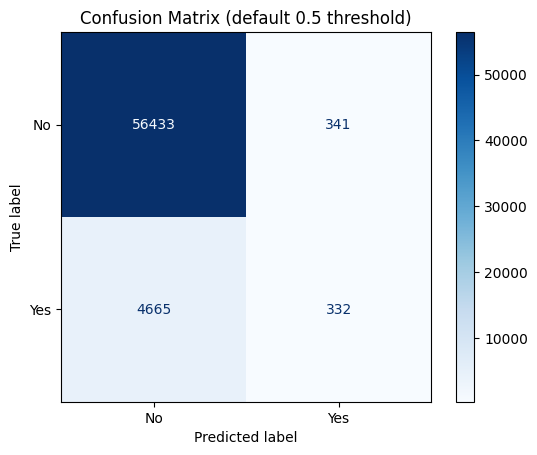

In [69]:
y_pred = best_pipeline.predict(X_test_scaled)
y_proba = best_pipeline.predict_proba(X_test_scaled)[:, 1]

print("Test set average precision:", average_precision_score(y_test, y_proba))
print("Test set ROC-AUC:", roc_auc_score(y_test, y_proba))
print()
print(classification_report(y_test, y_pred, target_names=["No", "Yes"]))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["No", "Yes"]).plot(cmap="Blues")
plt.title("Confusion Matrix (default 0.5 threshold)")
plt.show()

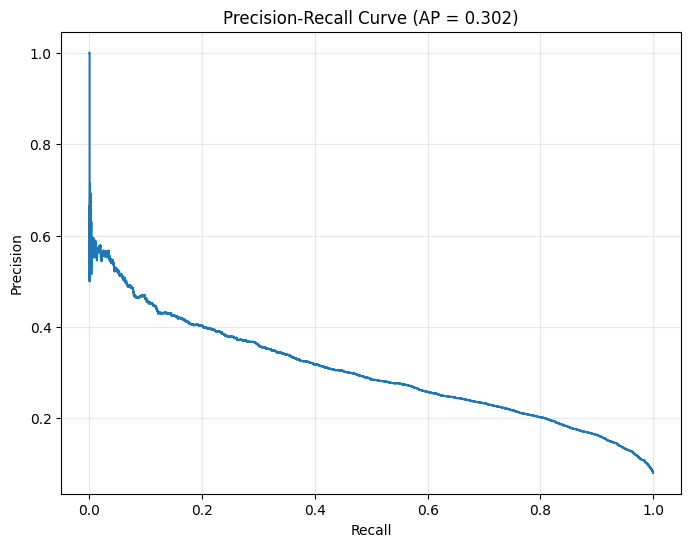

In [70]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(recalls, precisions)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve (AP = {average_precision_score(y_test, y_proba):.3f})")
plt.grid(alpha=0.3)
plt.show()

In [71]:
target_recall = 0.80
idx = np.argmin(np.abs(recalls - target_recall))
chosen_threshold = thresholds[idx] if idx < len(thresholds) else 0.5

y_pred_adjusted = (y_proba >= chosen_threshold).astype(int)

print(f"Threshold chosen for ~{target_recall:.0%} recall: {chosen_threshold:.4f}")
print(classification_report(y_test, y_pred_adjusted, target_names=["No", "Yes"]))

Threshold chosen for ~80% recall: 0.0924
              precision    recall  f1-score   support

          No       0.98      0.72      0.83     56774
         Yes       0.20      0.80      0.32      4997

    accuracy                           0.73     61771
   macro avg       0.59      0.76      0.58     61771
weighted avg       0.91      0.73      0.79     61771



In [72]:
model_bundle = {
    "pipeline": best_pipeline,
    "scaler": scaler,
    "label_encoder": le,
    "feature_columns": list(X.columns),
    "chosen_threshold": chosen_threshold,
}

joblib.dump(model_bundle, "/kaggle/working/cvd_model_bundle.pkl")
print("Saved model + scaler + threshold bundle to /kaggle/working/cvd_model_bundle.pkl")

Saved model + scaler + threshold bundle to /kaggle/working/cvd_model_bundle.pkl
